### Work to be done:
- Direct in_arches check using concat ID made using xmm_SRCID and gaia_DR3Name.
- Check for predicted positive pairs that don't exist in arches, so kinda same as 1st point.
- Check if the encoder is encoding XMM and Gaia Sources separately or if it's encoding a pair itself.
- Check for gaia object overlap in train and test
- Check if xmm_idx is assigning separate values to same xmm_SRCID

# Dual-Encoder Contrastive SSL for Cross-Matching

**Part 1:** Compare pair generation methods (d_MEC threshold vs shifted catalogue vs ARCHES)
**Part 2:** Train dual-encoder contrastive model — separate XMM and Gaia encoders learn a shared embedding space where true counterparts are close and spurious pairs are far apart.
**Part 3:** **Data Integrity:** We utilize `GroupShuffleSplit` grouped by XMM Source ID to prevent data leakage, ensuring the model generalizes to completely unseen X-ray sources.

No positional information enters the encoders. The model learns astrophysical consistency only for now.

In [1]:
# ================================================================
# 1. Imports and Global Configuration
# ================================================================
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.coordinates import SkyCoord, search_around_sky
import astropy.units as u

from scipy.stats import spearmanr, pearsonr, ks_2samp
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# --- CONFIGURATION ---
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 13})

DATA_DIR = "../Dataset"
SKIP_CLUSTER = "cluster_19"
SEED = 42

# Astrometry & Threshold Parameters
SEARCH_RADIUS = 17.0   # Maximum search radius in arcsec
SHIFT_ARCSEC = 60.0    # Shift for spurious pair generation
SIGMA_FACTOR = 3.0     # Threshold for d_MEC (Method A)
XMM_POSERR_FLOOR = 1.0 # Floor for XMM positional errors (PSF systematics)

# Training params
BATCH_SIZE = 512
EMBED_DIM = 64
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set Seeds
np.random.seed(42)
torch.manual_seed(42)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Data Loading Pipeline
We load the XMM, Gaia, and ARCHES (reference) catalogs across multiple clusters, explicitly filtering out corrupted files or specific test clusters.

In [2]:
# ================================================================
# 2. Multi-Cluster Data Loader
# ================================================================
data_dir = "../Dataset"

import glob
import os
import pandas as pd
from astropy.table import Table

def load_fits_to_df(directory, skip_cluster=None):
    all_dfs = []
    corrupt_files = [] 
    
    # Helper to convert object columns to strings
    def convert_object_columns_to_str(df):
        for col in df.select_dtypes(include=['object']).columns:
            df[col] = df[col].astype(str)
        return df
    
    for filepath in glob.glob(f"{directory}/*.fits"):
        filename = os.path.basename(filepath)
        
        # 1. Extract cluster name
        cluster_name = "unknown_cluster"
        if "cluster_" in filename:
            parts = filename.replace('.fits', '').split('_')
            for i, part in enumerate(parts):
                if part == 'cluster' and i + 1 < len(parts):
                    cluster_name = f"cluster_{parts[i+1]}"
                    break
        
        # 2. Skip logic
        if skip_cluster and cluster_name == skip_cluster:
            continue
            
        # 3. Read and Process
        try:
            table = Table.read(filepath)
            df = table.to_pandas()
            
            # Apply your conversion function here
            df = convert_object_columns_to_str(df)
            
            df["cluster"] = cluster_name 
            all_dfs.append(df)
            
        except (ValueError, TypeError, Exception) as e:
            corrupt_files.append((filename, str(e)))
            continue
            
    # [Summary and return code remains the same as your snippet]
    if corrupt_files:
        print(f"\n⚠️  [WARNING] Skipped {len(corrupt_files)} corrupted file(s) in '{directory}'")
    
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# Load and combine all files, explicitly skipping Cluster 19
# We use "cluster_19" as the substring to match your file naming convention
print("Loading FITS files\n")
gaia_df     = load_fits_to_df(f"{data_dir}/Gaia", skip_cluster="cluster_19")
xmm_df      = load_fits_to_df(f"{data_dir}/XMM", skip_cluster="cluster_19")
arches_df   = load_fits_to_df(f"{data_dir}/Xmatch_Arches", skip_cluster="cluster_19")

r_arches_fits_path = f"{data_dir}/reduced_xmm_gaiadr3_xmatch_new_poserr_cluster_20.fits"
r_arches_df = Table.read(r_arches_fits_path).to_pandas()

print("\nFITS files data loaded to Dataframes")

Loading FITS files


⚠️  [WARNING] Skipped 2 corrupted file(s) in '../Dataset/Gaia'

FITS files data loaded to Dataframes


## 2. Pair Construction (XMM × Gaia) & Method A Labeling
We perform a cross-match using a standard spatial search radius. To classify true vs. spurious pairs (Method A), we calculate the Mahalanobis distance ($d_{MEC}$ ) incorporating positional errors. 

**Important:** We enforce a 1.0 arcsec floor on XMM positional errors to account for physical PSF systematics.

In [3]:
# ================================================================
# 3. Spatial Cross-Matching and d_MEC Calculation
# ================================================================
# ================================================================
#  Pair construction + sigma floor + Method A labels
#  Everything in one cell — no duplication
# ================================================================

# ── Build pairs ───────────────────────────────────────────────

# Build spatial coordinates
xmm_coords  = SkyCoord(ra=xmm_df['xmm_SC_RA'].values  * u.deg,
                        dec=xmm_df['xmm_SC_DEC'].values * u.deg)
gaia_coords = SkyCoord(ra=gaia_df['gaia_RA_ICRS'].values * u.deg,
                        dec=gaia_df['gaia_DE_ICRS'].values * u.deg)

# Find all pairs within the SEARCH_RADIUS
idx_xmm, idx_gaia, sep2d, _ = search_around_sky(
    xmm_coords, gaia_coords, SEARCH_RADIUS * u.arcsec)

pairs = pd.DataFrame({
    'xmm_idx':   idx_xmm,
    'gaia_idx':  idx_gaia,
    'sep_arcsec': sep2d.arcsec
})

# Map features back to the pairs dataframe
xmm_reset  = xmm_df.iloc[idx_xmm].reset_index(drop=True)
gaia_reset = gaia_df.iloc[idx_gaia].reset_index(drop=True)

for col in xmm_df.columns:
    new_col = col if col.startswith('xmm_') else 'xmm_' + col
    pairs[new_col] = xmm_reset[col].values

for col in gaia_df.columns:
    new_col = col if col.startswith('gaia_') else 'gaia_' + col
    pairs[new_col] = gaia_reset[col].values

# ── Remove Duplicate Catalog Registrations ──────────
# Overlapping sky tiles/clusters can introduce identical XMM-Gaia source pairs.
# We drop them here to ensure downstream statistics and masks remain perfectly accurate.
initial_count = len(pairs)
pairs = pairs.drop_duplicates(subset=["xmm_SRCID", "gaia_DR3Name"]).copy()
dropped_count = initial_count - len(pairs)

# ── Compute d_MEC with XMM POSERR floor ──────────────────────
# XMM formal errors can be as small as 0.03 arcsec for bright sources
# but the true positional floor is ~1 arcsec (PSF systematics).
# Without this floor, d_MEC becomes artificially huge for nearby
# stars and the Rayleigh loss gets uninformative gradients.

XMM_POSERR_FLOOR = 1.0   # arcsec

sigma_xmm = pd.to_numeric(
    pairs['xmm_SC_POSERR'], errors='coerce'
).fillna(3.0).clip(lower=XMM_POSERR_FLOOR) / np.sqrt(2)

sigma_gaia = np.sqrt(
    (pd.to_numeric(pairs['gaia_e_RA_ICRS'], errors='coerce').fillna(0.001) / 1000)**2 +
    (pd.to_numeric(pairs['gaia_e_DE_ICRS'], errors='coerce').fillna(0.001) / 1000)**2
) / np.sqrt(2)

pairs['sigma_combined'] = np.sqrt(sigma_xmm**2 + sigma_gaia**2)
pairs['d_mec']          = pairs['sep_arcsec'] / pairs['sigma_combined']

# ── Method A labels ───────────────────────────────────────────
min_dmec = pairs.groupby('xmm_idx')['d_mec'].transform('min')
pairs['label_A'] = (
    (pairs['d_mec'] == min_dmec) &
    (pairs['d_mec'] < SIGMA_FACTOR)
).astype(float)

n_pos = (pairs['label_A'] == 1).sum()
n_neg = (pairs['label_A'] == 0).sum()

print(f"Total pairs:      {len(pairs):,}")
print(f"d_MEC max:        {pairs['d_mec'].max():.2f}  ") #(was 364 before floor)
print(f"d_MEC mean:       {pairs['d_mec'].mean():.2f}")
print()
print(f"Method A (d_MEC < {SIGMA_FACTOR}):")
print(f"  Positives: {n_pos:,}")
print(f"  Negatives: {n_neg:,}")
print(f"  Ratio:     1:{n_neg/max(n_pos,1):.1f}")
print(f"  Max d_MEC of positives: "
      f"{pairs.loc[pairs['label_A']==1,'d_mec'].max():.4f}")

Total pairs:      190,451
d_MEC max:        24.04  
d_MEC mean:       11.09

Method A (d_MEC < 3.0):
  Positives: 19,500
  Negatives: 170,951
  Ratio:     1:8.8
  Max d_MEC of positives: 2.9995


---
## 3.1 Three Pair Generation Methods

**Method A (d_MEC):** Best candidate per XMM source with d_MEC < 3.0 → positive, all others → negative.

## 3.2 Train / Validation / Test Splitting (Preventing Group Leakage)
Because a single XMM source can have multiple Gaia candidates, a random train/test split would scatter pairs from the same X-ray source across training and testing sets. This allows the model to "cheat" by memorizing source-specific features. 

**Fix:** We use `GroupShuffleSplit` grouped by `xmm_idx` to guarantee that all candidate pairs belonging to a specific XMM source are kept in the exact same data split.

In [4]:
# ================================================================
#  METHOD A: d_MEC threshold — fast vectorised
# ================================================================

min_dmec = pairs.groupby('xmm_idx')['d_mec'].transform('min')

pairs['label_A'] = (
    (pairs['d_mec'] == min_dmec) &
    (pairs['d_mec'] < SIGMA_FACTOR)
).astype(float)

n_pos_A = (pairs['label_A'] == 1).sum()
n_neg_A = (pairs['label_A'] == 0).sum()
print(f'Method A (d_MEC < {SIGMA_FACTOR}):')
print(f'  Pos: {n_pos_A:,} | Neg: {n_neg_A:,} | '
      f'Ratio 1:{n_neg_A/max(n_pos_A,1):.1f}')

Method A (d_MEC < 3.0):
  Pos: 19,500 | Neg: 170,951 | Ratio 1:8.8


In [5]:
# ================================================================
#  Confirm candidates per XMM source
# ================================================================
candidates_per_xmm = (
    pairs
    .groupby('xmm_idx')
    .size()
    .describe()
)
print("Gaia candidates per XMM source:")
print(candidates_per_xmm)

neg_xmm_counts = (
    pairs[pairs['label_A'] == 0]['xmm_idx']
    .value_counts()
    .describe()
)
print("\nXMM source repetition in Method A negatives:")
print(neg_xmm_counts)

Gaia candidates per XMM source:
count    35757.000000
mean         5.326258
std         11.936415
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        283.000000
dtype: float64

XMM source repetition in Method A negatives:
count    24583.000000
mean         6.954033
std         13.763833
min          1.000000
25%          1.000000
50%          1.000000
75%          5.000000
max        282.000000
Name: count, dtype: float64


Positives: 19,500
Negatives: 170,951
Ratio:     1:8.8


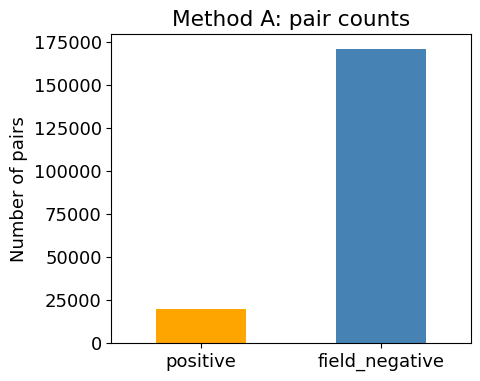

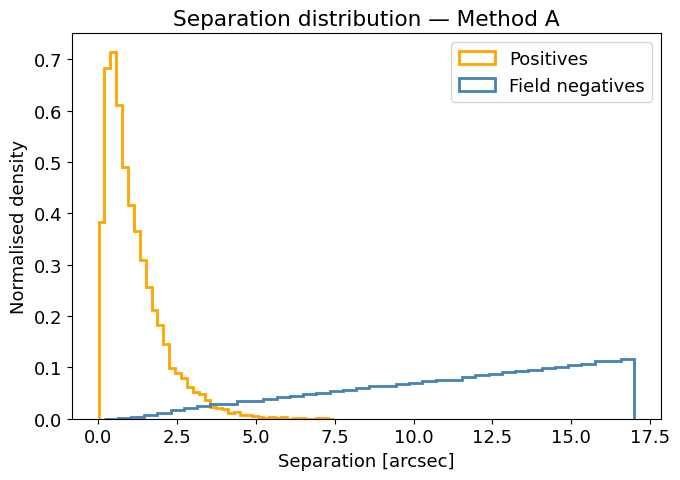

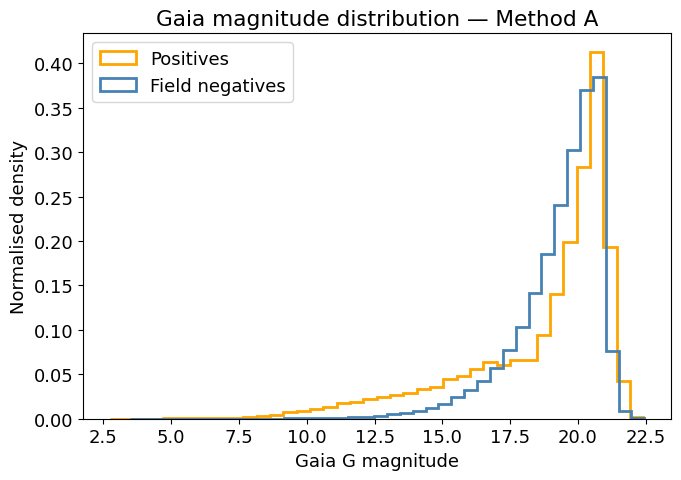

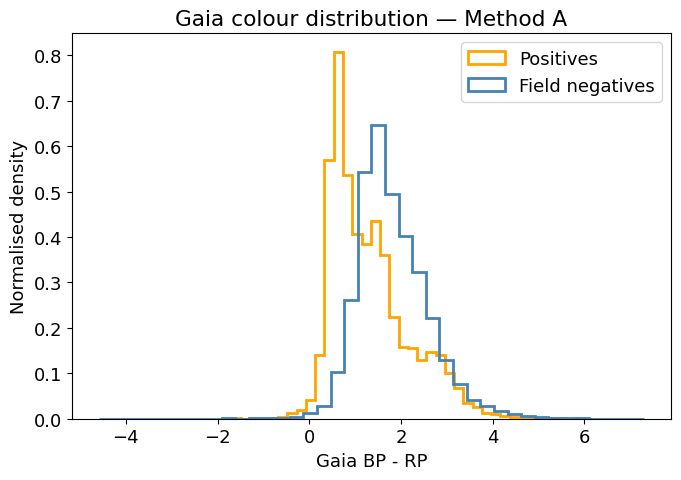

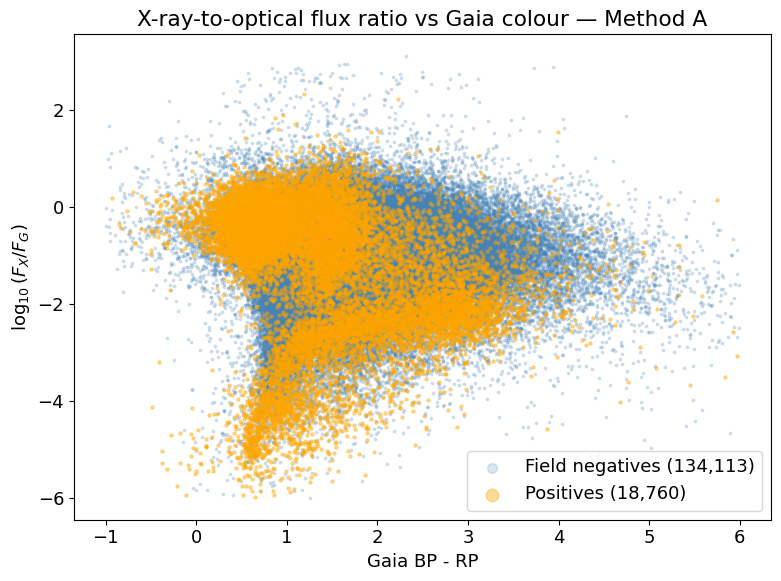

Positive points:       18,760 / 19,500


In [6]:
# ================================================================
#  DIAGNOSTIC PLOTS — METHOD A
# ================================================================

def add_fx_fg_columns(df):
    df = df.copy()
    for col in ['gaia_BPmag','gaia_RPmag','gaia_Gmag','xmm_SC_EP_8_FLUX']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['BP_RP']     = df['gaia_BPmag'] - df['gaia_RPmag']
    df['FG']        = 10**(-0.4 * df['gaia_Gmag']) * 4052.97 * 2.5e-9
    df['Fx_FG']     = df['xmm_SC_EP_8_FLUX'] / df['FG']
    df['log_Fx_FG'] = np.log10(df['Fx_FG'])
    return df.replace([np.inf, -np.inf], np.nan)

def make_plot_mask(df):
    return (
        np.isfinite(df['BP_RP']) & np.isfinite(df['log_Fx_FG']) &
        df['BP_RP'].between(-1, 6) & df['log_Fx_FG'].between(-6, 4)
    )

df_pos_A = pairs[pairs['label_A'] == 1].copy()
df_neg_A = pairs[pairs['label_A'] == 0].copy()

print(f"Positives: {len(df_pos_A):,}")
print(f"Negatives: {len(df_neg_A):,}")
print(f"Ratio:     1:{len(df_neg_A)/max(len(df_pos_A),1):.1f}")

# ── 1. Counts ─────────────────────────────────────────────────
plt.figure(figsize=(5, 4))
pd.Series({
    'positive':       len(df_pos_A),
    'field_negative': len(df_neg_A)
}).plot(kind='bar', color=['orange','steelblue'])
plt.ylabel('Number of pairs')
plt.title('Method A: pair counts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── 2. Separation distribution ─────────────────────────────────
plt.figure(figsize=(7, 5))
plt.hist(df_pos_A['sep_arcsec'].dropna(), bins=40, histtype='step',
         linewidth=2, density=True, color='orange', label='Positives')
plt.hist(df_neg_A['sep_arcsec'].dropna(), bins=40, histtype='step',
         linewidth=2, density=True, color='steelblue', label='Field negatives')
plt.xlabel('Separation [arcsec]')
plt.ylabel('Normalised density')
plt.title('Separation distribution — Method A')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Gaia G magnitude ────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.hist(pd.to_numeric(df_pos_A['gaia_Gmag'], errors='coerce').dropna(),
         bins=40, histtype='step', linewidth=2, density=True,
         color='orange', label='Positives')
plt.hist(pd.to_numeric(df_neg_A['gaia_Gmag'], errors='coerce').dropna(),
         bins=40, histtype='step', linewidth=2, density=True,
         color='steelblue', label='Field negatives')
plt.xlabel('Gaia G magnitude')
plt.ylabel('Normalised density')
plt.title('Gaia magnitude distribution — Method A')
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. BP-RP colour ────────────────────────────────────────────
df_pos_A['BP_RP'] = (pd.to_numeric(df_pos_A['gaia_BPmag'], errors='coerce')
                   - pd.to_numeric(df_pos_A['gaia_RPmag'], errors='coerce'))
df_neg_A['BP_RP'] = (pd.to_numeric(df_neg_A['gaia_BPmag'], errors='coerce')
                   - pd.to_numeric(df_neg_A['gaia_RPmag'], errors='coerce'))

plt.figure(figsize=(7, 5))
plt.hist(df_pos_A['BP_RP'].dropna(), bins=40, histtype='step',
         linewidth=2, density=True, color='orange', label='Positives')
plt.hist(df_neg_A['BP_RP'].dropna(), bins=40, histtype='step',
         linewidth=2, density=True, color='steelblue', label='Field negatives')
plt.xlabel('Gaia BP - RP')
plt.ylabel('Normalised density')
plt.title('Gaia colour distribution — Method A')
plt.legend()
plt.tight_layout()
plt.show()

# ── 5. Fx/Fg vs BP-RP scatter ──────────────────────────────────
df_pos_A = add_fx_fg_columns(df_pos_A)
df_neg_A = add_fx_fg_columns(df_neg_A)

pos_plot = df_pos_A[make_plot_mask(df_pos_A)]
neg_plot = df_neg_A[make_plot_mask(df_neg_A)]

plt.figure(figsize=(8, 6))
plt.scatter(neg_plot['BP_RP'], neg_plot['log_Fx_FG'],
            s=3, alpha=0.2, color='steelblue',
            label=f'Field negatives ({len(neg_plot):,})')
plt.scatter(pos_plot['BP_RP'], pos_plot['log_Fx_FG'],
            s=5, alpha=0.4, color='orange',
            label=f'Positives ({len(pos_plot):,})')
plt.xlabel('Gaia BP - RP')
plt.ylabel(r'$\log_{10}(F_X/F_G)$')
plt.title('X-ray-to-optical flux ratio vs Gaia colour — Method A')
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

print(f'Positive points:       {len(pos_plot):,} / {len(df_pos_A):,}')

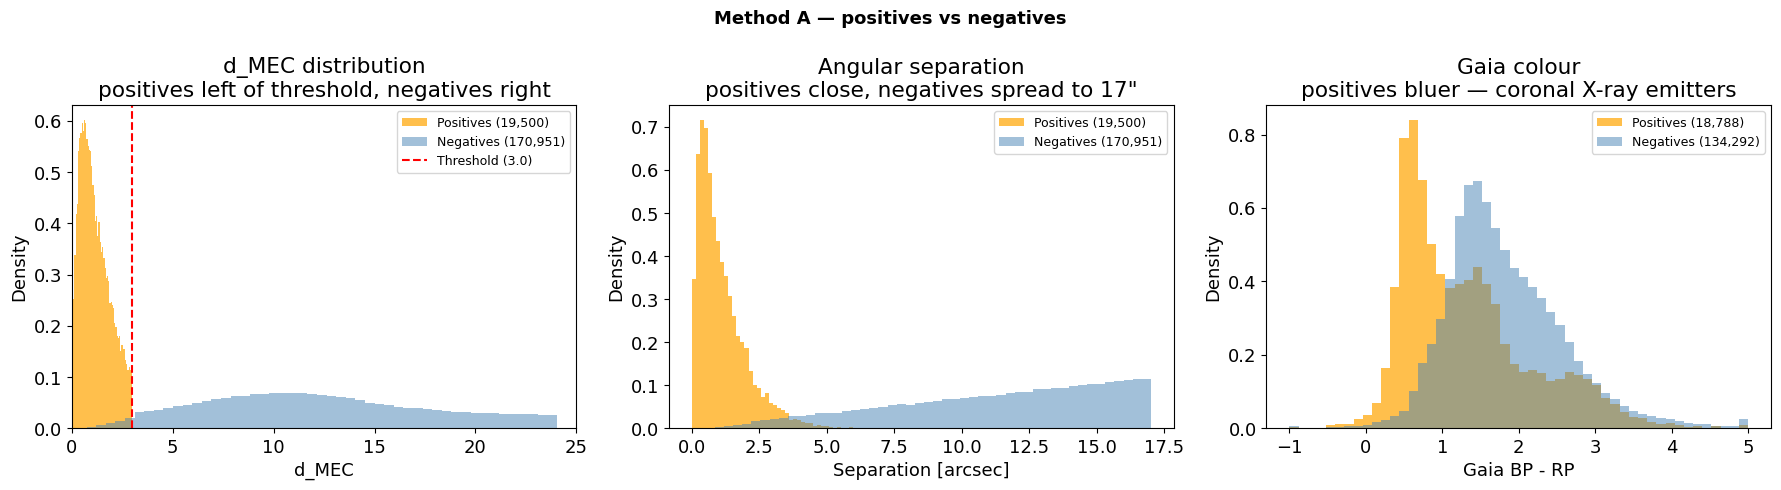

Positives: 19,500  |  max d_MEC: 2.9995
Negatives: 170,951  |  mean d_MEC: 12.22


In [7]:
# ================================================================
#  Method A: positives vs negatives — combined single row
# ================================================================

pos = pairs[pairs['label_A'] == 1].copy()
neg = pairs[pairs['label_A'] == 0].copy()

bp_rp_pos = (pd.to_numeric(pos['gaia_BPmag'], errors='coerce') -
             pd.to_numeric(pos['gaia_RPmag'], errors='coerce')).dropna()
bp_rp_neg = (pd.to_numeric(neg['gaia_BPmag'], errors='coerce') -
             pd.to_numeric(neg['gaia_RPmag'], errors='coerce')).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. d_MEC ──────────────────────────────────────────────────
ax = axes[0]
ax.hist(pos['d_mec'].dropna(), bins=50, density=True,
        alpha=0.7, color='orange', label=f'Positives ({len(pos):,})')
ax.hist(neg['d_mec'].dropna(), bins=50, density=True,
        alpha=0.5, color='steelblue', label=f'Negatives ({len(neg):,})')
ax.axvline(SIGMA_FACTOR, color='red', ls='--', lw=1.5,
           label=f'Threshold ({SIGMA_FACTOR})')
ax.set_xlim(0, 25)
ax.set_xlabel('d_MEC')
ax.set_ylabel('Density')
ax.set_title('d_MEC distribution\npositives left of threshold, negatives right')
ax.legend(fontsize=9)

# ── 2. Angular separation ─────────────────────────────────────
ax = axes[1]
ax.hist(pos['sep_arcsec'].dropna(), bins=50, density=True,
        alpha=0.7, color='orange', label=f'Positives ({len(pos):,})')
ax.hist(neg['sep_arcsec'].dropna(), bins=50, density=True,
        alpha=0.5, color='steelblue', label=f'Negatives ({len(neg):,})')
ax.set_xlabel('Separation [arcsec]')
ax.set_ylabel('Density')
ax.set_title('Angular separation\npositives close, negatives spread to 17"')
ax.legend(fontsize=9)

# ── 3. Gaia BP-RP colour ──────────────────────────────────────
ax = axes[2]
ax.hist(bp_rp_pos.clip(-1, 5), bins=50, density=True,
        alpha=0.7, color='orange', label=f'Positives ({len(bp_rp_pos):,})')
ax.hist(bp_rp_neg.clip(-1, 5), bins=50, density=True,
        alpha=0.5, color='steelblue', label=f'Negatives ({len(bp_rp_neg):,})')
ax.set_xlabel('Gaia BP - RP')
ax.set_ylabel('Density')
ax.set_title('Gaia colour\npositives bluer — coronal X-ray emitters')
ax.legend(fontsize=9)

plt.suptitle('Method A — positives vs negatives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Positives: {len(pos):,}  |  max d_MEC: {pos['d_mec'].max():.4f}")
print(f"Negatives: {len(neg):,}  |  mean d_MEC: {neg['d_mec'].mean():.2f}")

In [8]:
print(f"Total pairs: {len(pairs):,}")
print(f"\nd_MEC distribution of negatives:")
print(pairs[pairs['label_A']==0]['d_mec'].describe())
print(f"\nNegatives with d_MEC > SIGMA_FACTOR ({SIGMA_FACTOR}): "
      f"{(pairs[pairs['label_A']==0]['d_mec'] > SIGMA_FACTOR).sum():,}")
print(f"Negatives with d_MEC > 10: "
      f"{(pairs[pairs['label_A']==0]['d_mec'] > 10).sum():,}")
print(f"\nsep_arcsec of negatives:")
print(pairs[pairs['label_A']==0]['sep_arcsec'].describe())

Total pairs: 190,451

d_MEC distribution of negatives:
count    170951.000000
mean         12.222387
std           5.510640
min           0.262902
25%           8.001507
50%          11.713947
75%          16.165070
max          24.041537
Name: d_mec, dtype: float64

Negatives with d_MEC > SIGMA_FACTOR (3.0): 166,962
Negatives with d_MEC > 10: 105,628

sep_arcsec of negatives:
count    170951.000000
mean         11.368214
std           3.941888
min           0.185925
25%           8.519878
50%          12.024389
75%          14.723500
max          16.999945
Name: sep_arcsec, dtype: float64


In [9]:
print("sigma_combined distribution:")
print(pairs['sigma_combined'].describe())
print()
print("Very small sigma_combined (< 0.5 arcsec):")
print(f"  Count: {(pairs['sigma_combined'] < 0.5).sum():,}")
print(f"  Fraction: {100*(pairs['sigma_combined'] < 0.5).mean():.1f}%")
print()
print("sigma_xmm alone:")
sigma_xmm = pairs['xmm_SC_POSERR'].astype(float) / np.sqrt(2)
print(sigma_xmm.describe())
print()
print("sigma_gaia alone:")
sigma_gaia = np.sqrt(
    (pd.to_numeric(pairs['gaia_e_RA_ICRS'], errors='coerce')/1000)**2 +
    (pd.to_numeric(pairs['gaia_e_DE_ICRS'], errors='coerce')/1000)**2
) / np.sqrt(2)
print(sigma_gaia.describe())

sigma_combined distribution:
count    190451.000000
mean          1.002405
std           0.329940
min           0.707107
25%           0.707108
50%           0.918457
75%           1.197299
max           2.820259
Name: sigma_combined, dtype: float64

Very small sigma_combined (< 0.5 arcsec):
  Count: 0
  Fraction: 0.0%

sigma_xmm alone:
count    190451.000000
mean          0.917890
std           0.425702
min           0.030422
25%           0.585505
50%           0.918457
75%           1.197299
max           2.820259
Name: xmm_SC_POSERR, dtype: float64

sigma_gaia alone:
count    190451.000000
mean          0.001974
std           0.005294
min           0.000006
25%           0.000163
50%           0.000413
75%           0.001155
max           0.095779
dtype: float64


Positives : 19,500
Negatives : 170,951


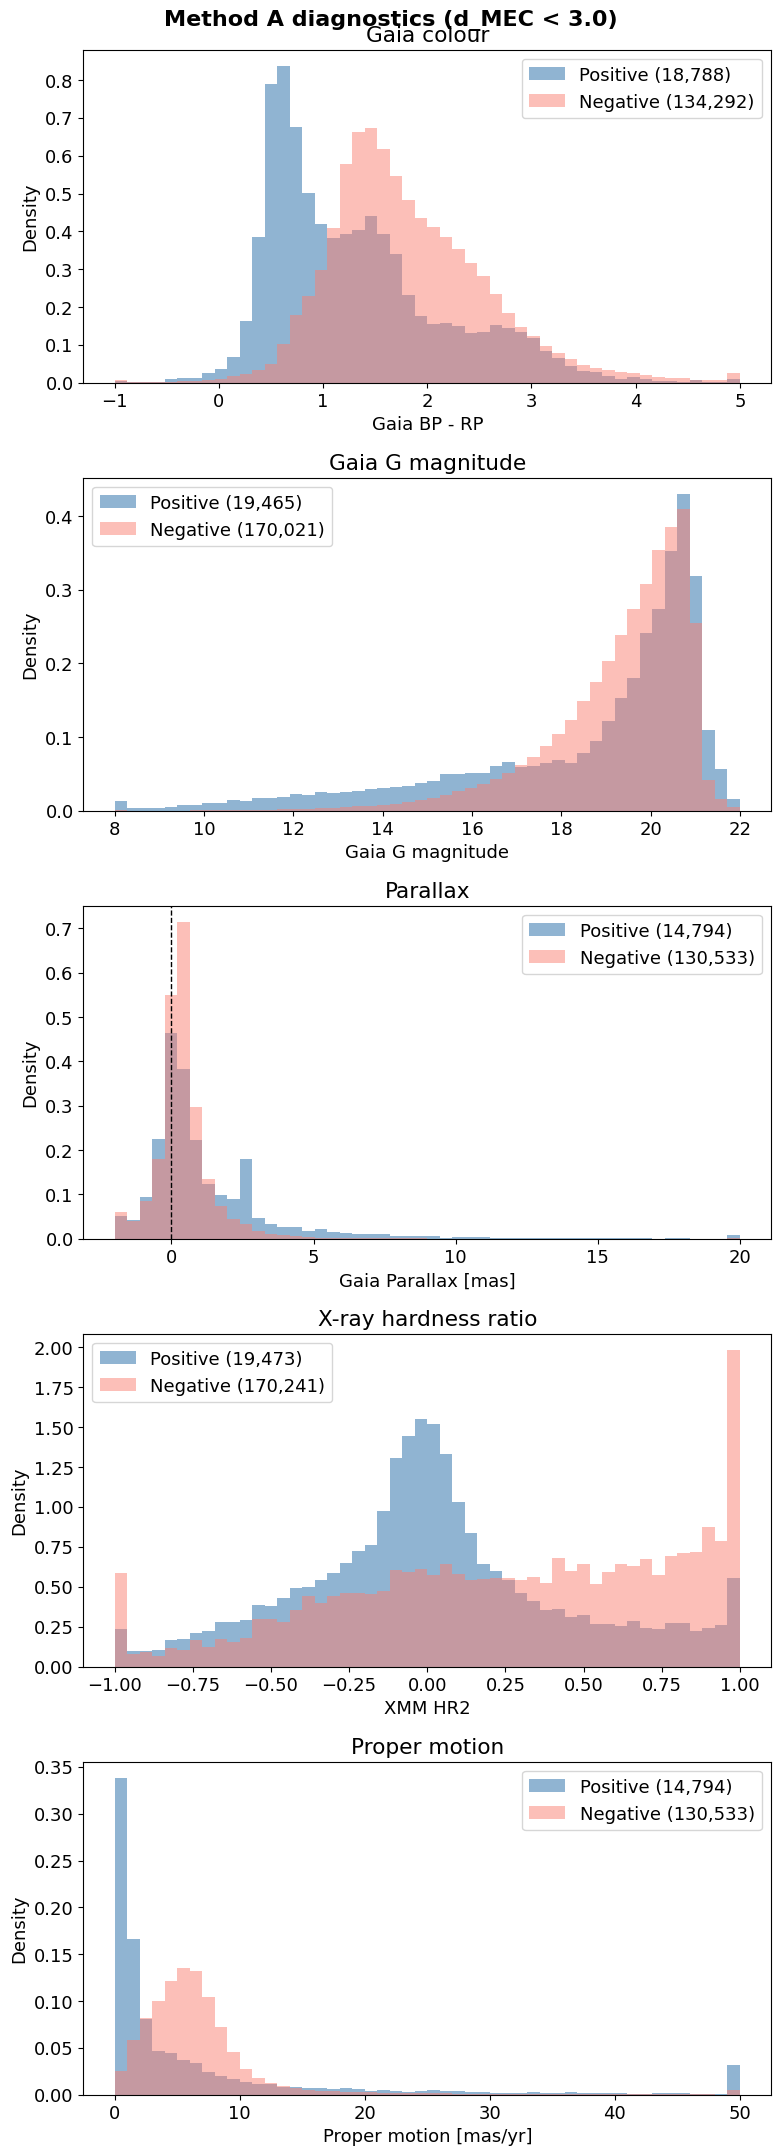

In [10]:
# ================================================================
# Positive vs Negative diagnostics
# METHOD A ONLY
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pos = pairs[pairs['label_A'] == 1].copy()
neg = pairs[pairs['label_A'] == 0].copy()

print(f"Positives : {len(pos):,}")
print(f"Negatives : {len(neg):,}")

fig, axes = plt.subplots(5, 1, figsize=(8, 22))

def to_num(df, col):
    return pd.to_numeric(df[col], errors='coerce')

# ==========================================================
# 1. Gaia BP-RP
# ==========================================================

bp_rp_pos = (
    to_num(pos,'gaia_BPmag')
    - to_num(pos,'gaia_RPmag')
).dropna()

bp_rp_neg = (
    to_num(neg,'gaia_BPmag')
    - to_num(neg,'gaia_RPmag')
).dropna()

axes[0].hist(
    bp_rp_pos.clip(-1,5),
    bins=50,
    density=True,
    alpha=0.6,
    color='steelblue',
    label=f'Positive ({len(bp_rp_pos):,})'
)

axes[0].hist(
    bp_rp_neg.clip(-1,5),
    bins=50,
    density=True,
    alpha=0.5,
    color='salmon',
    label=f'Negative ({len(bp_rp_neg):,})'
)

axes[0].set_xlabel('Gaia BP - RP')
axes[0].set_ylabel('Density')
axes[0].set_title('Gaia colour')
axes[0].legend()

# ==========================================================
# 2. Gaia G magnitude
# ==========================================================

g_pos = to_num(pos,'gaia_Gmag').dropna()
g_neg = to_num(neg,'gaia_Gmag').dropna()

axes[1].hist(
    g_pos.clip(8,22),
    bins=50,
    density=True,
    alpha=0.6,
    color='steelblue',
    label=f'Positive ({len(g_pos):,})'
)

axes[1].hist(
    g_neg.clip(8,22),
    bins=50,
    density=True,
    alpha=0.5,
    color='salmon',
    label=f'Negative ({len(g_neg):,})'
)

axes[1].set_xlabel('Gaia G magnitude')
axes[1].set_ylabel('Density')
axes[1].set_title('Gaia G magnitude')
axes[1].legend()

# ==========================================================
# 3. Gaia Parallax
# ==========================================================

plx_pos = to_num(pos,'gaia_Plx').dropna()
plx_neg = to_num(neg,'gaia_Plx').dropna()

axes[2].hist(
    plx_pos.clip(-2,20),
    bins=50,
    density=True,
    alpha=0.6,
    color='steelblue',
    label=f'Positive ({len(plx_pos):,})'
)

axes[2].hist(
    plx_neg.clip(-2,20),
    bins=50,
    density=True,
    alpha=0.5,
    color='salmon',
    label=f'Negative ({len(plx_neg):,})'
)

axes[2].axvline(0, ls='--', c='k', lw=1)

axes[2].set_xlabel('Gaia Parallax [mas]')
axes[2].set_ylabel('Density')
axes[2].set_title('Parallax')
axes[2].legend()

# ==========================================================
# 4. XMM HR2
# ==========================================================

hr2_pos = to_num(pos,'xmm_SC_HR2').dropna()
hr2_neg = to_num(neg,'xmm_SC_HR2').dropna()

axes[3].hist(
    hr2_pos.clip(-1,1),
    bins=50,
    density=True,
    alpha=0.6,
    color='steelblue',
    label=f'Positive ({len(hr2_pos):,})'
)

axes[3].hist(
    hr2_neg.clip(-1,1),
    bins=50,
    density=True,
    alpha=0.5,
    color='salmon',
    label=f'Negative ({len(hr2_neg):,})'
)

axes[3].set_xlabel('XMM HR2')
axes[3].set_ylabel('Density')
axes[3].set_title('X-ray hardness ratio')
axes[3].legend()

# ==========================================================
# 5. Proper Motion
# ==========================================================

pm_pos = np.sqrt(
    to_num(pos,'gaia_pmRA')**2 +
    to_num(pos,'gaia_pmDE')**2
).dropna()

pm_neg = np.sqrt(
    to_num(neg,'gaia_pmRA')**2 +
    to_num(neg,'gaia_pmDE')**2
).dropna()

axes[4].hist(
    pm_pos.clip(0,50),
    bins=50,
    density=True,
    alpha=0.6,
    color='steelblue',
    label=f'Positive ({len(pm_pos):,})'
)

axes[4].hist(
    pm_neg.clip(0,50),
    bins=50,
    density=True,
    alpha=0.5,
    color='salmon',
    label=f'Negative ({len(pm_neg):,})'
)

axes[4].set_xlabel('Proper motion [mas/yr]')
axes[4].set_ylabel('Density')
axes[4].set_title('Proper motion')
axes[4].legend()

plt.suptitle(
    f'Method A diagnostics (d_MEC < {SIGMA_FACTOR})',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# Gaia cuts + HRD quantities
# ================================================================

def apply_gaia_cuts_for_hrd(
    df,
    use_extinction_correction=True,
    parallax_snr_min=5,
    apply_quality_cuts=True
):
    """
    Apply Gaia quality cuts and create HRD columns.

    Returns dataframe with:
        color_BPRP
        absolute_G_mag
        Magnitude_corrected
        absolute_mag_corrected
    """

    df = df.copy()

    cols = [
        "gaia_Plx", "gaia_e_Plx",
        "gaia_Gmag", "gaia_BPmag", "gaia_RPmag",
        "gaia_e_RA_ICRS", "gaia_e_DE_ICRS",
        "gaia_FBP", "gaia_FRP", "gaia_RFG",
        "gaia_E(BP/RP)", "gaia_Nper",
        "gaia_Teff", "gaia_logg",
        "gaia_E(BP-RP)", "gaia_AG"
    ]

    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)

    # Basic validity before distance calculation
    df = df.dropna(
        subset=[
            "gaia_Plx",
            "gaia_Gmag",
            "gaia_BPmag",
            "gaia_RPmag"
        ]
    )

    df = df[df["gaia_Plx"] > 0].copy()

    df["distance_pc"] = 1000.0 / df["gaia_Plx"]
    df["color_BPRP"] = df["gaia_BPmag"] - df["gaia_RPmag"]
    df["absolute_G_mag"] = (
        df["gaia_Gmag"]
        - 5.0 * np.log10(df["distance_pc"] / 10.0)
    )

    if "gaia_e_Plx" in df.columns:
        df["plx_snr"] = df["gaia_Plx"] / df["gaia_e_Plx"]
    else:
        df["plx_snr"] = np.nan

    df["excess_max"] = 1.3 + 0.06 * df["color_BPRP"]**2
    df["excess_min"] = 1.0 + 0.015 * df["color_BPRP"]**2

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["absolute_G_mag", "color_BPRP"])

    if apply_quality_cuts:

        if "gaia_e_RA_ICRS" in df.columns:
            df = df[df["gaia_e_RA_ICRS"] <= 30]

        if "gaia_e_DE_ICRS" in df.columns:
            df = df[df["gaia_e_DE_ICRS"] <= 30]

        if "gaia_FBP" in df.columns:
            df = df[df["gaia_FBP"] > 20]

        if "gaia_FRP" in df.columns:
            df = df[df["gaia_FRP"] > 20]

        if "gaia_RFG" in df.columns:
            df = df[df["gaia_RFG"] > 50]

        if "gaia_Nper" in df.columns:
            df = df[df["gaia_Nper"] > 8]

        if "gaia_E(BP/RP)" in df.columns:
            df = df[df["gaia_E(BP/RP)"] < df["excess_max"]]
            df = df[df["gaia_E(BP/RP)"] > df["excess_min"]]

        if "gaia_e_Plx" in df.columns:
            df = df[df["plx_snr"] > parallax_snr_min]

    # Default: uncorrected values
    df["Magnitude_corrected"] = df["color_BPRP"]
    df["absolute_mag_corrected"] = df["absolute_G_mag"]

    if use_extinction_correction:

        if ("gaia_Teff" in df.columns) and ("gaia_logg" in df.columns):
            extinction_mask = (
                df["gaia_Teff"].between(3500, 10000)
                &
                df["gaia_logg"].between(2.5, 4.0)
            )
        else:
            extinction_mask = pd.Series(False, index=df.index)

        if extinction_mask.any() and "gaia_E(BP-RP)" in df.columns:
            df.loc[extinction_mask, "Magnitude_corrected"] = (
                df.loc[extinction_mask, "color_BPRP"]
                - df.loc[extinction_mask, "gaia_E(BP-RP)"]
            )

        if extinction_mask.any() and "gaia_AG" in df.columns:
            df.loc[extinction_mask, "absolute_mag_corrected"] = (
                df.loc[extinction_mask, "absolute_G_mag"]
                - df.loc[extinction_mask, "gaia_AG"]
            )

    df = df.replace([np.inf, -np.inf], np.nan)

    df = df.dropna(
        subset=[
            "Magnitude_corrected",
            "absolute_mag_corrected"
        ]
    )

    return df

Method A: 20,041 sources after Gaia cuts


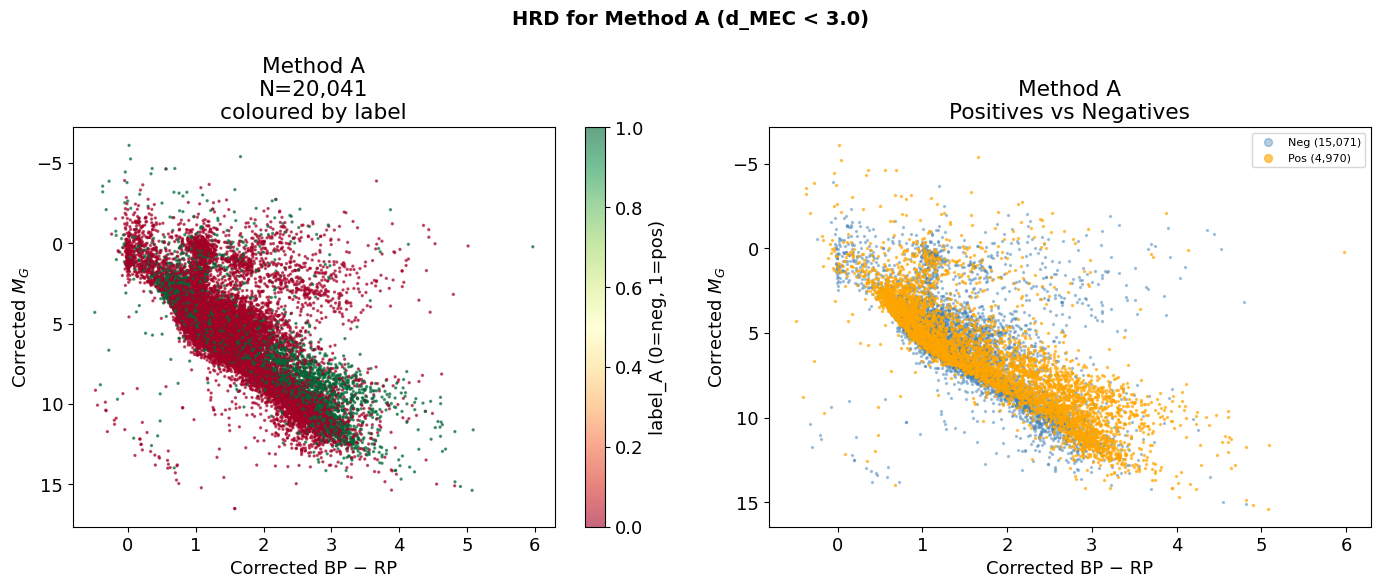

In [12]:
# ================================================================
# HRD for Method A only
# ================================================================

base = pairs[pairs['label_A'].notna()].copy()

hrd = apply_gaia_cuts_for_hrd(base)

print(f'Method A: {len(hrd):,} sources after Gaia cuts')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================================
# Panel 1: HRD coloured by label
# ==========================================================

plot_df = hrd.sample(
    n=min(50000, len(hrd)),
    random_state=42
)

sc = axes[0].scatter(
    plot_df['Magnitude_corrected'],
    plot_df['absolute_mag_corrected'],
    c=plot_df['label_A'],
    s=2,
    alpha=0.6,
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    rasterized=True
)

axes[0].invert_yaxis()
axes[0].set_xlabel('Corrected BP − RP')
axes[0].set_ylabel(r'Corrected $M_G$')
axes[0].set_title(
    f'Method A\nN={len(plot_df):,}\ncoloured by label'
)

plt.colorbar(
    sc,
    ax=axes[0],
    label='label_A (0=neg, 1=pos)'
)

# ==========================================================
# Panel 2: Positives vs negatives
# ==========================================================

pos_hrd = hrd[hrd['label_A'] == 1]
neg_hrd = hrd[hrd['label_A'] == 0]

n_show = min(
    len(pos_hrd),
    len(neg_hrd),
    20000
)

neg_sample = neg_hrd.sample(
    n=min(n_show, len(neg_hrd)),
    random_state=42
)

pos_sample = pos_hrd.sample(
    n=min(n_show, len(pos_hrd)),
    random_state=42
)

axes[1].scatter(
    neg_sample['Magnitude_corrected'],
    neg_sample['absolute_mag_corrected'],
    s=2,
    alpha=0.4,
    color='steelblue',
    label=f'Neg ({len(neg_hrd):,})',
    rasterized=True
)

axes[1].scatter(
    pos_sample['Magnitude_corrected'],
    pos_sample['absolute_mag_corrected'],
    s=2,
    alpha=0.6,
    color='orange',
    label=f'Pos ({len(pos_hrd):,})',
    rasterized=True
)

axes[1].invert_yaxis()
axes[1].set_xlabel('Corrected BP − RP')
axes[1].set_ylabel(r'Corrected $M_G$')
axes[1].set_title('Method A\nPositives vs Negatives')
axes[1].legend(fontsize=8, markerscale=4)

plt.suptitle(
    f'HRD for Method A (d_MEC < {SIGMA_FACTOR})',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Feature separation for Method A
KS statistic: higher = stronger separation

Feature                           KS      p-value      N_pos      N_neg
---------------------------------------------------------------------------
xmm_SC_HR2                     0.297*     0.00e+00     19,473    170,241
xmm_SC_HR3                     0.199*     0.00e+00     19,470    169,889
gaia_Gmag                      0.145*    9.29e-322     19,465    170,021
gaia_BP_RP                     0.359*     0.00e+00     18,788    134,292
xmm_SC_EP_8_FLUX               0.130*    1.45e-256     19,500    170,951
xmm_SC_FVAR                    0.095*     1.59e-47      7,399     31,573
gaia_pmRA                      0.411*     0.00e+00     14,794    130,533
gaia_Plx                       0.203*     0.00e+00     14,794    130,533

* = statistically significant, p < 0.05

Top 4 separating features for Method A:
  gaia_pmRA                 KS=0.411, p=0.00e+00
  gaia_BP_RP                KS=0.359, p=0.00e+00
  xmm_SC_HR2

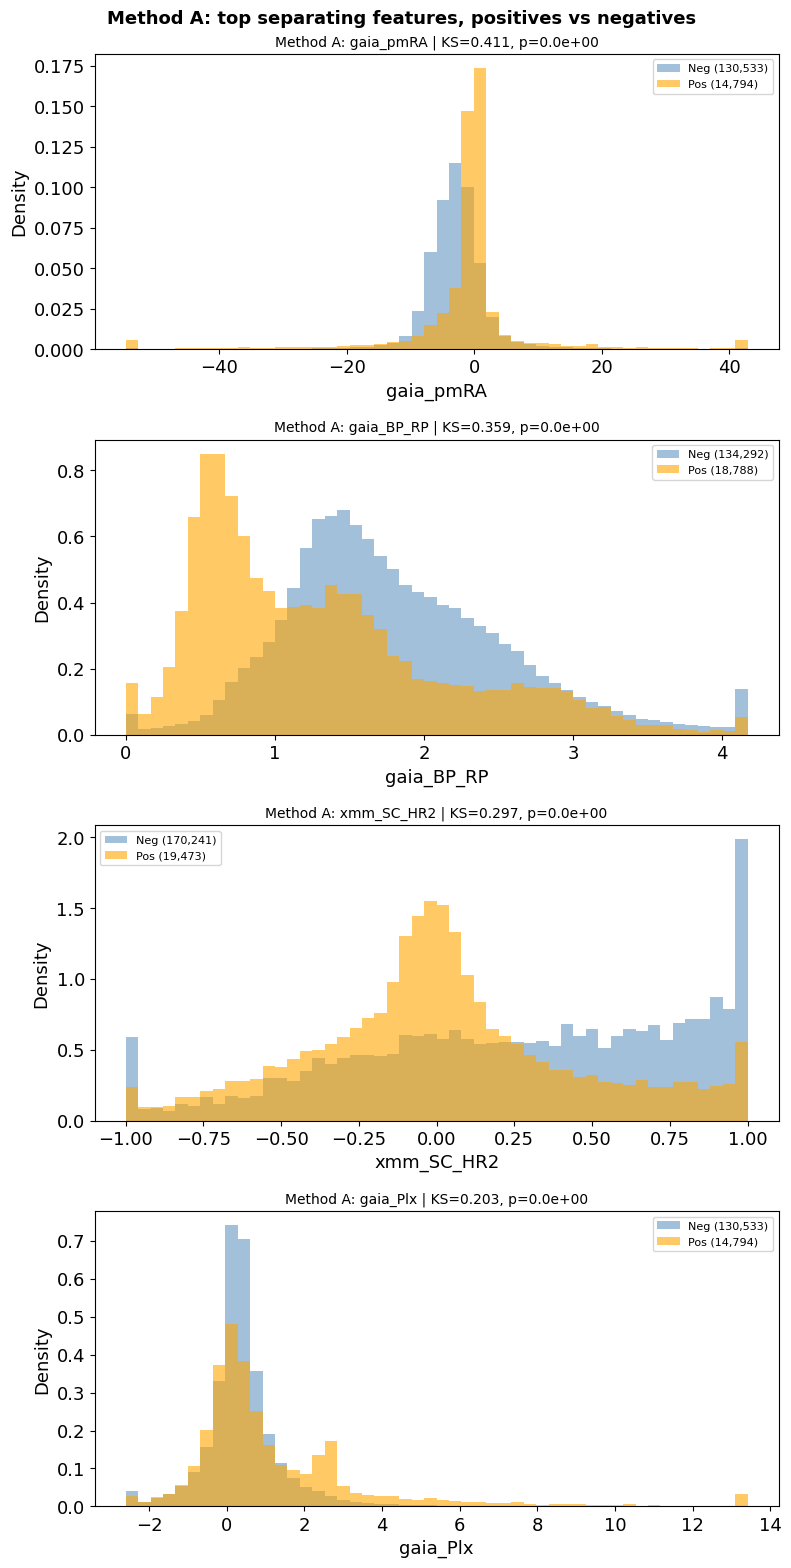

In [13]:
# ================================================================
# Physical feature comparison: KS tests
# METHOD A ONLY
# ================================================================

from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# Add BP-RP if not already present
# ------------------------------------------------

if "gaia_BP_RP" not in pairs.columns:
    pairs["gaia_BP_RP"] = (
        pd.to_numeric(pairs["gaia_BPmag"], errors="coerce")
        - pd.to_numeric(pairs["gaia_RPmag"], errors="coerce")
    )

# ------------------------------------------------
# Features to test
# ------------------------------------------------

test_cols = [
    c for c in [
        "xmm_SC_HR2",
        "xmm_SC_HR3",
        "gaia_Gmag",
        "gaia_BP_RP",
        "xmm_SC_EP_8_FLUX",
        "xmm_SC_FVAR",
        "gaia_pmRA",
        "gaia_Plx"
    ]
    if c in pairs.columns
]

# ------------------------------------------------
# Use Method A only
# ------------------------------------------------

base = pairs.copy()
pos_mask = base["label_A"] == 1
neg_mask = base["label_A"] == 0

print("Feature separation for Method A")
print("KS statistic: higher = stronger separation")
print()
print(f'{"Feature":<25} {"KS":>10} {"p-value":>12} {"N_pos":>10} {"N_neg":>10}')
print("-" * 75)

ks_scores_A = []

for col in test_cols:

    vals = pd.to_numeric(base[col], errors="coerce")

    pos = vals[pos_mask].dropna()
    neg = vals[neg_mask].dropna()

    if len(pos) > 10 and len(neg) > 10:
        ks, pval = ks_2samp(pos, neg)
        ks_scores_A.append((col, ks, pval, len(pos), len(neg)))

        sig = "*" if pval < 0.05 else " "

        print(
            f"{col:<25} "
            f"{ks:>10.3f}{sig} "
            f"{pval:>12.2e} "
            f"{len(pos):>10,} "
            f"{len(neg):>10,}"
        )

    else:
        print(
            f"{col:<25} "
            f"{'N/A':>10} "
            f"{'N/A':>12} "
            f"{len(pos):>10,} "
            f"{len(neg):>10,}"
        )

print()
print("* = statistically significant, p < 0.05")
print()

# ------------------------------------------------
# Sort and show top features
# ------------------------------------------------

top_features = sorted(
    ks_scores_A,
    key=lambda x: x[1],
    reverse=True
)[:4]

print(f"Top {len(top_features)} separating features for Method A:")
for col, ks, pval, npos, nneg in top_features:
    print(f"  {col:<25} KS={ks:.3f}, p={pval:.2e}")

# ------------------------------------------------
# Plot distributions for top features
# ------------------------------------------------

if len(top_features) > 0:

    fig, axes = plt.subplots(
        len(top_features),
        1,
        figsize=(8, 4 * len(top_features))
    )

    if len(top_features) == 1:
        axes = [axes]

    for row_i, (col, _, _, _, _) in enumerate(top_features):

        ax = axes[row_i]

        vals = pd.to_numeric(base[col], errors="coerce")

        pos = vals[pos_mask].dropna()
        neg = vals[neg_mask].dropna()

        if len(pos) > 10 and len(neg) > 10:

            ks, pval = ks_2samp(pos, neg)

            lo = min(
                np.percentile(pos, 1),
                np.percentile(neg, 1)
            )

            hi = max(
                np.percentile(pos, 99),
                np.percentile(neg, 99)
            )

            ax.hist(
                neg.clip(lo, hi),
                bins=50,
                density=True,
                alpha=0.5,
                color="steelblue",
                label=f"Neg ({len(neg):,})"
            )

            ax.hist(
                pos.clip(lo, hi),
                bins=50,
                density=True,
                alpha=0.6,
                color="orange",
                label=f"Pos ({len(pos):,})"
            )

            ax.set_title(
                f"Method A: {col} | KS={ks:.3f}, p={pval:.1e}",
                fontsize=10
            )

        else:
            ax.set_title(f"Method A: {col} | N/A", fontsize=10)
            ax.text(
                0.5,
                0.5,
                "Not enough data",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

    plt.suptitle(
        "Method A: top separating features, positives vs negatives",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

##### 
The KS statistic measures how different the positive and negative distributions are for each feature. 
- A score of 0 means identical distributions: the model cannot learn anything from that feature. 
- A score of 1 means completely separated: perfect discrimination.

Method A- has consistently high KS across all features. Every single feature is statistically significant. This means positives and negatives are genuinely different in multiple independent ways — the model has a rich, multi-dimensional signal to learn from.

Method B (ARCHES) - has uniformly low KS scores, roughly half of Method A's values. This is the class imbalance problem. With 94% positives and 6% negatives, ARCHES has very few negatives to compare against, so the distributions look similar even when they aren't. Method B has too few negatives to reveal the separation.

Method C (shifted) has mixed scores. HR2 (0.281) and flux (0.257) are actually higher than Method A — but for the wrong reason. The shifted negatives are random Gaia stars paired with random XMM sources, so the XMM features in the shifted negatives span the full XMM flux and hardness range, making the separation look artificially large. BP-RP (0.161) is lower than Method A (0.260) because the shifted Gaia stars span all colours, diluting the real astrophysical colour preference of true counterparts.


- Feature            -Method A    -Method C    -Interpretation
- gaia_BP_RP         -0.260       -0.161       -A better — real sky colour preference
- gaia_pmRA          -0.225       -0.216       -Similar — both capture stellar motion
- xmm_SC_HR2         -0.223       -0.281       -C higher — but artificially inflated
- gaia_Plx           -0.219       -0.191       -A better — real parallax signal

Method A's negatives are harder. They are real stars inside the XMM error circle, so their colour, parallax, and proper motion distributions are similar to the positives. A KS of 0.260 for BP-RP in Method A is genuinely earned. The model must learn a subtle colour preference. Method C's lower BP-RP KS (0.161) means the shifted negatives are too easy on colour — any random Gaia star is obviously the wrong colour.

---
## 5. Define XMM and Gaia Feature Sets (SEPARATE — no mixing)

We define the XMM and Gaia features that the encoders will ingest. 
**Crucial Note:** `xmm_SC_RA`, `xmm_SC_DEC`, `gaia_RA_ICRS`, `gaia_DE_ICRS`, `sep_arcsec`, and `d_mec` are strictly excluded from these lists so the model learns purely astrophysical parameters, not positional distance.

We'll explore geometric features in the future.

In [14]:
# ================================================================
#  XMM features — what the X-ray telescope measured
#  NO positions, NO Gaia information
# ================================================================
xmm_feature_candidates = [
    'xmm_SC_HR1', 'xmm_SC_HR2', 'xmm_SC_HR3', 'xmm_SC_HR4',
    'xmm_SC_EP_8_FLUX', 'xmm_SC_EP_1_FLUX', 'xmm_SC_EP_2_FLUX',
    'xmm_SC_EP_3_FLUX', 'xmm_SC_EP_4_FLUX', 'xmm_SC_EP_5_FLUX',
    'xmm_SC_FVAR', 'xmm_SC_EXTENT', 
    'xmm_SC_EP_8_FMIN', 'xmm_SC_EP_8_FMAX',
    'xmm_PN_TEXP_2', 'xmm_EP_ONTIME',
    'xmm_SC_CHI2PROB', 'xmm_EP_OFFAX', 
    'xmm_LII', 'xmm_SC_RA', 'xmm_SC_DEC', 'xmm_SC_POSERR', #'xmm_SC_DET_ML',
    
]

# Gaia features — what the optical telescope measured
# NO positions, NO XMM information
gaia_feature_candidates = [
    'gaia_Gmag', 'gaia_BPmag', 'gaia_RPmag',
    'gaia_FG', 'gaia_FBP', 'gaia_FRP',
    'gaia_Plx', 'gaia_e_Plx',
    'gaia_pmRA', 'gaia_pmDE', 'gaia_e_pmRA', 'gaia_e_pmDE',
    'gaia_Teff', 'gaia_logg', 'gaia_[Fe/H]',
    'gaia_RV', 'gaia_AG', 'gaia_E(BP-RP)', 'gaia_E(BP/RP)',
    'gaia_RFG', 'gaia_RFBP', 'gaia_RFRP',
    'gaia_chi2AL', 'gaia_Nper',
    'gaia_DR3Name'
]

# Filter to what actually exists and has data
def filter_features(candidates, df, min_valid=100):
    cols = []
    for c in candidates:
        if c in df.columns:
            try:
                vals = pd.to_numeric(df[c], errors='coerce')
                if vals.notna().sum() > min_valid:
                    cols.append(c)
            except:
                pass
    return cols

xmm_features = filter_features(xmm_feature_candidates, pairs)
gaia_features = filter_features(gaia_feature_candidates, pairs)

print(f'XMM features: {len(xmm_features)}')
for c in xmm_features:
    miss = pd.to_numeric(pairs[c], errors='coerce').isna().sum()
    print(f'  {c:<30} miss={miss:,} ({100*miss/len(pairs):.1f}%)')

print(f'\nGaia features: {len(gaia_features)}')
for c in gaia_features:
    miss = pd.to_numeric(pairs[c], errors='coerce').isna().sum()
    print(f'  {c:<30} miss={miss:,} ({100*miss/len(pairs):.1f}%)')

XMM features: 22
  xmm_SC_HR1                     miss=1,844 (1.0%)
  xmm_SC_HR2                     miss=737 (0.4%)
  xmm_SC_HR3                     miss=1,092 (0.6%)
  xmm_SC_HR4                     miss=1,953 (1.0%)
  xmm_SC_EP_8_FLUX               miss=0 (0.0%)
  xmm_SC_EP_1_FLUX               miss=0 (0.0%)
  xmm_SC_EP_2_FLUX               miss=0 (0.0%)
  xmm_SC_EP_3_FLUX               miss=0 (0.0%)
  xmm_SC_EP_4_FLUX               miss=0 (0.0%)
  xmm_SC_EP_5_FLUX               miss=0 (0.0%)
  xmm_SC_FVAR                    miss=151,479 (79.5%)
  xmm_SC_EXTENT                  miss=0 (0.0%)
  xmm_SC_EP_8_FMIN               miss=0 (0.0%)
  xmm_SC_EP_8_FMAX               miss=0 (0.0%)
  xmm_PN_TEXP_2                  miss=0 (0.0%)
  xmm_EP_ONTIME                  miss=0 (0.0%)
  xmm_SC_CHI2PROB                miss=135,344 (71.1%)
  xmm_EP_OFFAX                   miss=0 (0.0%)
  xmm_LII                        miss=0 (0.0%)
  xmm_SC_RA                      miss=0 (0.0%)
  xmm_SC_DEC   

---
## 6. Preprocessing (shared — run once, reused by all three models)

KNN-imputation and StandardScaling are fit on the **full** pairs table once.
Each method will use the same scaled feature matrices; only the label vector `y` changes.

In [15]:
# Use only Method A labelled rows
method_A_mask = pairs["label_A"].notna()
pairs_A = pairs.loc[method_A_mask].copy()

# Reassign xmm_idx to use the unique astronomical source ID
pairs_A['xmm_idx'] = pairs_A['xmm_SRCID']

print(f"Using {len(pairs_A):,} Method A labelled rows")

Using 190,451 Method A labelled rows


In [16]:
# # ================================================================
# # Preprocessing — Method A only
# # Fit imputer/scaler on Method A labelled rows with TQDM Tracker
# # ================================================================

# import numpy as np
# import pandas as pd
# from fknni import FaissImputer
# from sklearn.preprocessing import StandardScaler
# from tqdm.auto import tqdm  # <--- Added for real-time progress tracking

# # ------------------------------------------------
# # Raw features
# # ------------------------------------------------
# X_xmm_raw_A = (
#     pairs_A[xmm_features].apply(pd.to_numeric, errors="coerce").astype("float64")
# )

# X_gaia_raw_A = (
#     pairs_A[gaia_features].apply(pd.to_numeric, errors="coerce").astype("float64")
# )

# # ------------------------------------------------
# # Batch-based GPU Imputation Function with TQDM Tracker
# # ------------------------------------------------
# def batch_impute_with_progress(X_df, n_neighbors=5, batch_size=10000, desc=""):
#     """Splits data into batches to feed the C++ GPU engine sequentially,
#     allowing TQDM to render a real-time progress bar.
#     """
#     X_values = X_df.values
#     n_samples = len(X_values)
#     imputer = FaissImputer(n_neighbors=n_neighbors)

#     # Pre-allocate output array
#     X_out = np.empty_like(X_values)

#     # Initialize TQDM progress bar
#     with tqdm(total=n_samples, desc=desc, unit="rows") as pbar:
#         for i in range(0, n_samples, batch_size):
#             batch = X_values[i : i + batch_size]

#             # Process the batch using the GPU-accelerated engine
#             imputed_batch = imputer.fit_transform(batch)

#             # Store results
#             X_out[i : i + batch_size] = imputed_batch

#             # Update live visual bar
#             pbar.update(len(batch))

#     # Run clean-up transformations
#     return np.nan_to_num(X_out, nan=0, posinf=0, neginf=0)


# # ------------------------------------------------
# # Fit GPU-accelerated imputers (With TQDM Progress Bars)
# # ------------------------------------------------
# print("\n--- Initializing Live GPU Imputation Progress ---")

# # Adjust batch_size depending on your DGX memory (10,000 to 50,000 is usually ideal)
# BATCH_SIZE = 25000

# X_xmm_imp_A = batch_impute_with_progress(
#     X_xmm_raw_A, n_neighbors=16, batch_size=BATCH_SIZE, desc="⏳ Imputing XMM Matrix"
# )

# X_gaia_imp_A = batch_impute_with_progress(
#     X_gaia_raw_A, n_neighbors=16, batch_size=BATCH_SIZE, desc="⏳ Imputing GAIA Matrix"
# )

# # ------------------------------------------------
# # Fit scalers on Method A rows
# # ------------------------------------------------
# scaler_xmm = StandardScaler()
# scaler_gaia = StandardScaler()

# X_xmm = scaler_xmm.fit_transform(X_xmm_imp_A).astype("float32")
# X_gaia = scaler_gaia.fit_transform(X_gaia_imp_A).astype("float32")

# # ------------------------------------------------
# # Labels and groups
# # ------------------------------------------------
# y_A = pairs_A["label_A"].astype("float32").values
# groups = pairs_A["xmm_idx"].values

# print("\n--- Data Summary ---")
# print(f"X_xmm  shape: {X_xmm.shape}")
# print(f"X_gaia shape: {X_gaia.shape}")
# print(f"y_A    shape: {y_A.shape}")
# print(f"groups shape: {groups.shape}")

# print("\nPreprocessing complete for Method A (Tracked with TQDM).")

In [17]:
# # ------------------------------------------------
# # Save the processed features
# # ------------------------------------------------
# # Pass the index of pairs_A so your rows stay perfectly mapped to your source data
# pd.DataFrame(X_xmm, columns=xmm_features, index=pairs_A.index).to_parquet("X_xmm_fknni_imputed.parquet")
# pd.DataFrame(X_gaia, columns=gaia_features, index=pairs_A.index).to_parquet("X_gaia_fknni_imputed.parquet")

# print("Successfully saved X_xmm and X_gaia to disk.")

In [18]:
# Load your processed features back into DataFrames
X_xmm_df = pd.read_parquet("X_xmm_fknni_imputed.parquet")
X_gaia_df = pd.read_parquet("X_gaia_fknni_imputed.parquet")

# If you need them as NumPy arrays for your model input:
X_xmm = X_xmm_df.values.astype("float32")
X_gaia = X_gaia_df.values.astype("float32")
# ------------------------------------------------
# Labels and groups (Unchanged)
# ------------------------------------------------

y_A = pairs_A["label_A"].astype("float32").values
groups = pairs_A["xmm_idx"].values

print(f"X_xmm  shape: {X_xmm.shape}")
print(f"X_gaia shape: {X_gaia.shape}")
print(f"y_A    shape: {y_A.shape}")
print(f"groups shape: {groups.shape}")


X_xmm  shape: (190451, 22)
X_gaia shape: (190451, 24)
y_A    shape: (190451,)
groups shape: (190451,)


---
## 7. Dual-Encoder Architecture & Loss


In [19]:
# ================================================================
# Pure SSL Dual Encoder Model
# No ARCHES used in training
# ================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(64, embed_dim)
        )

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, p=2, dim=1)


class DualEncoderCrossMatch(nn.Module):
    def __init__(self, xmm_dim, gaia_dim, embed_dim=64):
        super().__init__()

        self.xmm_encoder = Encoder(xmm_dim, embed_dim)
        self.gaia_encoder = Encoder(gaia_dim, embed_dim)

        # Trainable mapping from similarity to probability
        self.beta = nn.Parameter(torch.tensor(5.0))
        self.bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, x_xmm, x_gaia):
        z_xmm = self.xmm_encoder(x_xmm)
        z_gaia = self.gaia_encoder(x_gaia)
        return z_xmm, z_gaia

    # use cosine similarity or InfoNCE
    def similarity(self, z_xmm, z_gaia):
        return F.cosine_similarity(z_xmm, z_gaia, dim=1)
#         return (z_xmm * z_gaia).sum(dim=1)

    def logits(self, z_xmm, z_gaia):
        sim = self.similarity(z_xmm, z_gaia)

        beta = torch.clamp(self.beta, min=0.1, max=50.0)
        return beta * sim + self.bias

    def probability(self, z_xmm, z_gaia):
        return torch.sigmoid(self.logits(z_xmm, z_gaia))
    
    
    
    
    
# ================================================================
# Loss functions
# ================================================================

def contrastive_bce_loss(model, z_xmm, z_gaia, labels):
    """
    Supervised part:
    label_A = 1 should get high probability.
    label_A = 0 should get low probability.
    """
    logits = model.logits(z_xmm, z_gaia)
    return F.binary_cross_entropy_with_logits(logits, labels)


def rayleigh_mixture_loss(model, z_xmm, z_gaia, d_mec, dmax, eps=1e-12):
    """
    Astrometric SSL part.

    True counterparts:
        d_mec follows Rayleigh distribution.

    Random alignments:
        d_mec follows background distribution p(d) ∝ d.

    The network does NOT see d_mec as input.
    d_mec only teaches the model what match-like pairs should look like.
    """

    prob = model.probability(z_xmm, z_gaia)

    d = d_mec.clamp(min=1e-6, max=dmax)

    Z = 1.0 - torch.exp(
        torch.tensor(-0.5 * dmax**2, device=d.device)
    )

    rayleigh = (
        d * torch.exp(-0.5 * d**2) / Z
    ).clamp(min=eps)

    background = (
        2.0 * d / dmax**2
    ).clamp(min=eps)

    mixture = (
        prob * rayleigh
        + (1.0 - prob) * background
    ).clamp(min=eps)

    return -torch.log(mixture).mean()


def combined_ssl_loss(
    model,
    z_xmm,
    z_gaia,
    labels,
    d_mec,
    dmax,
    alpha_c=0.7,
    alpha_r=0.3
):
    Lc = contrastive_bce_loss(model, z_xmm, z_gaia, labels)
    Lr = rayleigh_mixture_loss(model, z_xmm, z_gaia, d_mec, dmax=dmax)

    loss = alpha_c * Lc + alpha_r * Lr

    return loss, Lc, Lr

---
## 8. Dataset Spliting
To prevent test-set data leakage into our training data, we fit our Imputer and Scaler **strictly on the Training set** before transforming the Validation and Test sets.

In [20]:
# ================================================================
# Data loader
# ================================================================

def make_loader(Xx, Xg, y, dm, batch_size=512, shuffle=True):
    ds = TensorDataset(
        torch.tensor(Xx, dtype=torch.float32),
        torch.tensor(Xg, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(dm, dtype=torch.float32)
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=shuffle
    )

In [57]:
# import networkx as nx
# import numpy as np
# import pandas as pd

# # ================================================================
# # Data Splitting: Rigorous Graph + Spatial Longitude (70/20/10)
# # ================================================================

# # 1. Build the Bipartite Graph for Zero Source Leakage
# G = nx.Graph()
# edges = [("x_" + str(x), "g_" + str(g)) for x, g in zip(pairs_A['xmm_SRCID'], pairs_A['gaia_DR3Name'])]
# G.add_edges_from(edges)

# components = list(nx.connected_components(G))
# node_to_comp = {node: comp_id for comp_id, comp_nodes in enumerate(components) for node in comp_nodes}

# # Map every row in your dataset to its strict graph component ID
# pairs_A['comp_id'] = [node_to_comp["x_" + str(x)] for x in pairs_A['xmm_SRCID']]

# # 2. Calculate Spatial Metrics per Component
# # (Assuming 'xmm_SC_RA' is your longitude column. Adjust if named differently in pairs_A)
# longitude_col = 'xmm_SC_RA'

# comp_stats = pairs_A.groupby('comp_id').agg(
#     pair_count=('comp_id', 'count'),
#     mean_lon=(longitude_col, 'mean')
# ).reset_index()

# # 3. Sort Spatially (This creates the longitudinal regions)
# comp_stats = comp_stats.sort_values('mean_lon').reset_index(drop=True)

# # 4. Cumulative Partitioning (70/20/10)
# total_pairs = comp_stats['pair_count'].sum()
# comp_stats['cumulative_pairs'] = comp_stats['pair_count'].cumsum()
# comp_stats['cumulative_ratio'] = comp_stats['cumulative_pairs'] / total_pairs

# def assign_split(ratio):
#     if ratio <= 0.70:
#         return 'train'
#     elif ratio <= 0.90:  # 70% Train + 20% Val = 90%
#         return 'val'
#     else:
#         return 'test'

# comp_stats['split_label'] = comp_stats['cumulative_ratio'].apply(assign_split)

# # 5. Extract Absolute Indices for DataLoaders
# # Create a dictionary to map component IDs to their assigned split
# comp_to_split = dict(zip(comp_stats['comp_id'], comp_stats['split_label']))

# # Create an array that holds the split label ('train', 'val', 'test') for every row in pairs_A
# row_splits = np.array([comp_to_split[cid] for cid in pairs_A['comp_id']])

# # Generate the absolute indices (matching the logic of your previous setup)
# all_indices = np.arange(len(pairs_A))

# train_idx = all_indices[row_splits == 'train']
# val_idx   = all_indices[row_splits == 'val']
# test_idx  = all_indices[row_splits == 'test']

# # Extract distance matrix (as in your original code)
# d_mec_A = pd.to_numeric(pairs_A["d_mec"], errors="coerce").values.astype("float32")

# # ================================================================
# # Verification
# # ================================================================
# print(f"Total Rows: {len(pairs_A):,}")
# print(f"Train Set: {len(train_idx):,} rows ({len(train_idx)/len(pairs_A):.1%})")
# print(f"Val Set:   {len(val_idx):,} rows ({len(val_idx)/len(pairs_A):.1%})")
# print(f"Test Set:  {len(test_idx):,} rows ({len(test_idx)/len(pairs_A):.1%})")

In [58]:
import networkx as nx
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd

# 1. Generate Connected Components as the robust grouping variable
G = nx.Graph()
edges = [("x_" + str(x), "g_" + str(g)) for x, g in zip(pairs_A['xmm_SRCID'], pairs_A['gaia_DR3Name'])]
G.add_edges_from(edges)

components = list(nx.connected_components(G))
node_to_comp = {node: comp_id for comp_id, comp_nodes in enumerate(components) for node in comp_nodes}

# Map back to create the leakage-proof group array
robust_groups = np.array([node_to_comp["x_" + str(x)] for x in pairs_A['xmm_SRCID']])

# Extract distance matrix
d_mec_A = pd.to_numeric(pairs_A["d_mec"], errors="coerce").values.astype("float32")

# 2. Split out the Test Set (10%) using the robust groups
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_xmm, y_A, groups=robust_groups))

# 3. Split the remaining 90% into Train (80% total) and Val (10% total)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1111, random_state=42)
train_idx_rel, val_idx_rel = next(gss_val.split(X_xmm[train_val_idx], y_A[train_val_idx], groups=robust_groups[train_val_idx]))

# Map relative validation indices back to absolute original indices
train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]

print(f"Train Set: {len(train_idx):,} rows | {len(set(robust_groups[train_idx])):,} unique graph components")
print(f"Val Set:   {len(val_idx):,} rows | {len(set(robust_groups[val_idx])):,} unique graph components")
print(f"Test Set:  {len(test_idx):,} rows | {len(set(robust_groups[test_idx])):,} unique graph components")

Train Set: 152,962 rows | 28,071 unique graph components
Val Set:   18,841 rows | 3,509 unique graph components
Test Set:  18,648 rows | 3,509 unique graph components


In [59]:
# Create DataLoaders
train_loader = make_loader(X_xmm[train_idx], X_gaia[train_idx], y_A[train_idx], d_mec_A[train_idx], batch_size=512, shuffle=True)
val_loader = make_loader(X_xmm[val_idx], X_gaia[val_idx], y_A[val_idx], d_mec_A[val_idx], batch_size=512, shuffle=False)
test_loader = make_loader(X_xmm[test_idx], X_gaia[test_idx], y_A[test_idx], d_mec_A[test_idx], batch_size=512, shuffle=False)

In [60]:
# Define the column that uniquely identifies a Gaia source
gaia_col = 'gaia_DR3Name' 

# Extract unique Gaia sources for each split
train_gaia = set(pairs_A.iloc[train_idx][gaia_col])
val_gaia = set(pairs_A.iloc[val_idx][gaia_col])
test_gaia = set(pairs_A.iloc[test_idx][gaia_col])

# All unique Gaia sources across the entire dataset splits combined
all_unique_gaia = train_gaia.union(val_gaia).union(test_gaia)

# Calculate intersections between the sets
train_val_overlap = train_gaia.intersection(val_gaia)
train_test_overlap = train_gaia.intersection(test_gaia)
val_test_overlap = val_gaia.intersection(test_gaia)

# Total unique leaked Gaia sources across any split boundary
all_leaked_gaia = train_val_overlap.union(train_test_overlap).union(val_test_overlap)

# Print Raw Counts
print("--- Absolute Counts ---")
print(f"Total Unique Gaia Sources across all splits: {len(all_unique_gaia)}")
print(f"Unique Gaia sources in Train: {len(train_gaia)}")
print(f"Unique Gaia sources in Val:   {len(val_gaia)}")
print(f"Unique Gaia sources in Test:  {len(test_gaia)}")
print(f"Gaia sources in BOTH Train and Val:   {len(train_val_overlap)}")
print(f"Gaia sources in BOTH Train and Test:  {len(train_test_overlap)}")
print(f"Gaia sources in BOTH Val and Test:   {len(val_test_overlap)}")

# Print Overlap Percentages relative to each split
print("\n--- Overlap % Relative to Each Split ---")
if len(train_gaia) > 0:
    print(f"Train Overlap with Val:  {(len(train_val_overlap) / len(train_gaia)) * 100:.2f}%")
    print(f"Train Overlap with Test: {(len(train_test_overlap) / len(train_gaia)) * 100:.2f}%")

if len(val_gaia) > 0:
    print(f"Val Overlap with Train:  {(len(train_val_overlap) / len(val_gaia)) * 100:.2f}%")
    print(f"Val Overlap with Test:   {(len(val_test_overlap) / len(val_gaia)) * 100:.2f}%")

if len(test_gaia) > 0:
    print(f"Test Overlap with Train: {(len(train_test_overlap) / len(test_gaia)) * 100:.2f}%")
    print(f"Test Overlap with Val:   {(len(val_test_overlap) / len(test_gaia)) * 100:.2f}%")

# Print Overlap Percentages relative to the overall unique dataset
print("\n--- Overlap % Relative to Overall Unique Dataset ---")
if len(all_unique_gaia) > 0:
    print(f"Train/Val Overlap vs Overall:  {(len(train_val_overlap) / len(all_unique_gaia)) * 100:.2f}%")
    print(f"Train/Test Overlap vs Overall: {(len(train_test_overlap) / len(all_unique_gaia)) * 100:.2f}%")
    print(f"Val/Test Overlap vs Overall:  {(len(val_test_overlap) / len(all_unique_gaia)) * 100:.2f}%")
    print(f"Total Leaked Gaia Sources vs Overall: {(len(all_leaked_gaia) / len(all_unique_gaia)) * 100:.2f}%")

# Evaluate overall leakage
if len(all_leaked_gaia) > 0:
    print("\n⚠️ Data Leakage Detected: Some Gaia sources appear in multiple splits.")
else:
    print("\n✅ Success: No Gaia source leakage across splits.")

--- Absolute Counts ---
Total Unique Gaia Sources across all splits: 188328
Unique Gaia sources in Train: 151251
Unique Gaia sources in Val:   18638
Unique Gaia sources in Test:  18439
Gaia sources in BOTH Train and Val:   0
Gaia sources in BOTH Train and Test:  0
Gaia sources in BOTH Val and Test:   0

--- Overlap % Relative to Each Split ---
Train Overlap with Val:  0.00%
Train Overlap with Test: 0.00%
Val Overlap with Train:  0.00%
Val Overlap with Test:   0.00%
Test Overlap with Train: 0.00%
Test Overlap with Val:   0.00%

--- Overlap % Relative to Overall Unique Dataset ---
Train/Val Overlap vs Overall:  0.00%
Train/Test Overlap vs Overall: 0.00%
Val/Test Overlap vs Overall:  0.00%
Total Leaked Gaia Sources vs Overall: 0.00%

✅ Success: No Gaia source leakage across splits.


---
## 9. Training Block

In [61]:
import os
from sklearn.metrics import roc_auc_score, average_precision_score

# ================================================================
# Train pure SSL model with Targeted Checkpointing
# ================================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

# Create the save directory if it doesn't already exist
checkpoint_dir = "./Models"
os.makedirs(checkpoint_dir, exist_ok=True)

d_mec_A = pd.to_numeric(pairs_A["d_mec"], errors="coerce").values.astype("float32")

model = DualEncoderCrossMatch(
    xmm_dim=X_xmm.shape[1],
    gaia_dim=X_gaia.shape[1],
    embed_dim=64
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

N_EPOCHS = 50

# Track the best validation metric
metric_to_track = 'val_roc' 
best_val_auc = -1.0  

for epoch in range(N_EPOCHS):

    model.train()

    total_loss = 0.0
    total_Lc = 0.0
    total_Lr = 0.0
    n_batches = 0

    for xb_xmm, xb_gaia, yb, db in train_loader:

        xb_xmm = xb_xmm.to(device)
        xb_gaia = xb_gaia.to(device)
        yb = yb.to(device)
        db = db.to(device)

        optimizer.zero_grad()

        z_xmm, z_gaia = model(xb_xmm, xb_gaia)

        loss, Lc, Lr = combined_ssl_loss(
            model,
            z_xmm,
            z_gaia,
            yb,
            db,
            dmax=SIGMA_FACTOR,
            alpha_c=0.7,
            alpha_r=0.3
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_Lc += Lc.item()
        total_Lr += Lr.item()
        n_batches += 1
    
    train_loss = total_loss / n_batches
    
    # -------- VALIDATION PHASE --------
    model.eval()
    val_loss = 0.0
    val_batches = 0
    all_val_preds = []
    all_val_targets = []
    
    with torch.no_grad():
        for xb_xmm, xb_gaia, yb, db in val_loader:
            xb_xmm, xb_gaia, yb, db = xb_xmm.to(device), xb_gaia.to(device), yb.to(device), db.to(device)
            
            z_xmm, z_gaia = model(xb_xmm, xb_gaia)
            loss, _, _ = combined_ssl_loss(
                model, z_xmm, z_gaia, yb, db, 
                dmax=SIGMA_FACTOR, alpha_c=0.7, alpha_r=0.3
            )
            
            val_loss += loss.item()
            val_batches += 1
            
            probs = model.probability(z_xmm, z_gaia)
            all_val_preds.extend(probs.cpu().numpy())
            all_val_targets.extend(yb.cpu().numpy())

    val_loss = val_loss / val_batches
    
    # Calculate robust metrics
    try:
        val_roc = roc_auc_score(all_val_targets, all_val_preds)
        val_pr = average_precision_score(all_val_targets, all_val_preds)
    except ValueError:
        val_roc, val_pr = 0.0, 0.0 

    current_auc = val_roc if metric_to_track == 'val_roc' else val_pr

    # --- Checkpoint Management ---
    status_msg = ""
    if current_auc > best_val_auc:
        best_val_auc = current_auc
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_roc': val_roc,
            'val_pr': val_pr,
            'train_loss': train_loss,
            'val_loss': val_loss
        }
        
        # Combined explicit file path
        save_path = os.path.join(checkpoint_dir, 'best_dual_encoder_model.pt')
        torch.save(checkpoint, save_path)
        status_msg = f" || [Saved to {save_path}! Metric: {best_val_auc:.4f}]"

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val ROC-AUC={val_roc:.4f} | "
        f"Val PR-AUC={val_pr:.4f} | "
        f"beta={model.beta.item():.2f} | "
        f"bias={model.bias.item():.3f}"
        f"{status_msg}"
    )

Epoch 001 | Train Loss=0.3134 | Val Loss=0.2867 | Val ROC-AUC=0.9157 | Val PR-AUC=0.7131 | beta=5.13 | bias=-0.043 || [Saved to ./Models/best_dual_encoder_model.pt! Metric: 0.9157]
Epoch 002 | Train Loss=0.2811 | Val Loss=0.2840 | Val ROC-AUC=0.9213 | Val PR-AUC=0.7425 | beta=5.22 | bias=-0.064 || [Saved to ./Models/best_dual_encoder_model.pt! Metric: 0.9213]
Epoch 003 | Train Loss=0.2749 | Val Loss=0.2748 | Val ROC-AUC=0.9266 | Val PR-AUC=0.7620 | beta=5.29 | bias=-0.084 || [Saved to ./Models/best_dual_encoder_model.pt! Metric: 0.9266]
Epoch 004 | Train Loss=0.2717 | Val Loss=0.2758 | Val ROC-AUC=0.9278 | Val PR-AUC=0.7650 | beta=5.36 | bias=-0.105 || [Saved to ./Models/best_dual_encoder_model.pt! Metric: 0.9278]
Epoch 005 | Train Loss=0.2697 | Val Loss=0.2714 | Val ROC-AUC=0.9298 | Val PR-AUC=0.7734 | beta=5.43 | bias=-0.127 || [Saved to ./Models/best_dual_encoder_model.pt! Metric: 0.9298]
Epoch 006 | Train Loss=0.2679 | Val Loss=0.2696 | Val ROC-AUC=0.9311 | Val PR-AUC=0.7773 | beta

In [62]:
# 1. Instantiate the model framework with matching dimensions
best_model = DualEncoderCrossMatch(
    xmm_dim=X_xmm.shape[1],
    gaia_dim=X_gaia.shape[1],
    embed_dim=64
).to(device)

# 2. Load the dictionary map from disk
checkpoint = torch.load('./Models/best_dual_encoder_model.pt', map_location=device)

# 3. Inject the trained weights into the model architecture
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

print(f"Successfully loaded best model from Epoch {checkpoint['epoch']}.")
print(f"Loaded Model Performance Metrics -> ROC-AUC: {checkpoint['val_roc']:.4f}, PR-AUC: {checkpoint['val_pr']:.4f}")

Successfully loaded best model from Epoch 50.
Loaded Model Performance Metrics -> ROC-AUC: 0.9357, PR-AUC: 0.7928


---
## Model Testing and ARCHES comparison

In [63]:
# ================================================================
# Final Test Phase Evaluation
# ================================================================

print("\n--- Running Final Test Evaluation ---")
best_model.eval()
all_test_preds, all_test_targets = [], []

with torch.no_grad():
    for xb_xmm, xb_gaia, yb, db in test_loader:
        xb_xmm, xb_gaia = xb_xmm.to(device), xb_gaia.to(device)
        z_xmm, z_gaia = best_model(xb_xmm, xb_gaia)
        probs = best_model.probability(z_xmm, z_gaia)
        
        all_test_preds.extend(probs.cpu().numpy())
        all_test_targets.extend(yb.numpy())

test_roc = roc_auc_score(all_test_targets, all_test_preds)
test_pr = average_precision_score(all_test_targets, all_test_preds)

print(f"Test ROC-AUC: {test_roc:.4f}")
print(f"Test PR-AUC:  {test_pr:.4f}")


--- Running Final Test Evaluation ---
Test ROC-AUC: 0.9405
Test PR-AUC:  0.8008


In [64]:
# ================================================================
# Compute SSL match probabilities
# ================================================================

best_model.eval()

with torch.no_grad():

    Xx_t = torch.tensor(X_xmm, dtype=torch.float32).to(device)
    Xg_t = torch.tensor(X_gaia, dtype=torch.float32).to(device)

    z_xmm, z_gaia = best_model(Xx_t, Xg_t)

    sim_ssl = best_model.similarity(z_xmm, z_gaia)
    prob_ssl = best_model.probability(z_xmm, z_gaia)

pairs_A["sim_ssl"] = sim_ssl.cpu().numpy()
pairs_A["prob_ssl"] = prob_ssl.cpu().numpy()

print(pairs_A[["label_A", "d_mec", "sim_ssl", "prob_ssl"]].head())

   label_A     d_mec   sim_ssl  prob_ssl
0      0.0  9.188632 -0.595432  0.008286
1      0.0  6.543759 -0.590869  0.008548
2      0.0  8.981325 -0.574081  0.009581
3      0.0  9.635330 -0.489938  0.016938
4      0.0  6.574956 -0.501236  0.015695


In [65]:
# ================================================================
# Add ARCHES proba_xg to pairs_A
# ================================================================

def clean_id(x):
    if pd.isna(x):
        return ""
    try:
        return str(int(float(x)))
    except Exception:
        return str(x).strip()

def clean_name(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

# Make keys in pairs_A
pairs_A["xmm_SRCID_clean"] = pairs_A["xmm_SRCID"].apply(clean_id)
pairs_A["gaia_DR3Name_clean"] = pairs_A["gaia_DR3Name"].apply(clean_name)

pairs_A["xmm_gaia_key"] = (
    pairs_A["xmm_SRCID_clean"]
    + "_"
    + pairs_A["gaia_DR3Name_clean"]
)

# Make keys in arches_df
arches_tmp = arches_df.copy()

arches_tmp["xmm_SRCID_clean"] = arches_tmp["xmm_SRCID"].apply(clean_id)
arches_tmp["gaia_DR3Name_clean"] = arches_tmp["gaia_DR3Name"].apply(clean_name)

arches_tmp["xmm_gaia_key"] = (
    arches_tmp["xmm_SRCID_clean"]
    + "_"
    + arches_tmp["gaia_DR3Name_clean"]
)

arches_small = arches_tmp[["xmm_gaia_key", "proba_xg"]].copy()

arches_small["proba_xg"] = pd.to_numeric(
    arches_small["proba_xg"],
    errors="coerce"
)

# If duplicate keys exist, keep highest ARCHES probability
arches_small = (
    arches_small
    .sort_values("proba_xg", ascending=False)
    .drop_duplicates("xmm_gaia_key")
)

# Merge into pairs_A
pairs_A = pairs_A.drop(
    columns=["proba_xg", "proba_xg_x", "proba_xg_y"],
    errors="ignore"
)

pairs_A = pairs_A.merge(
    arches_small,
    on="xmm_gaia_key",
    how="left"
)

# Create the in_ARCHES flag immediately after the merge
pairs_A["in_arches"] = pairs_A["proba_xg"].notna()

print("pairs_A rows:", len(pairs_A))
print("Matched to ARCHES:", pairs_A["proba_xg"].notna().sum())
print("Unmatched:", pairs_A["proba_xg"].isna().sum())

pairs_A rows: 190451
Matched to ARCHES: 24429
Unmatched: 166022


In [66]:
# ================================================================
# Compare pure SSL probability with ARCHES proba_xg
# ARCHES is NOT used in training
# ================================================================

from scipy.stats import spearmanr, pearsonr


compare = pairs_A.copy()

compare["proba_xg"] = pd.to_numeric(compare["proba_xg"], errors="coerce")
compare["prob_ssl"] = pd.to_numeric(compare["prob_ssl"], errors="coerce")
compare["d_mec"] = pd.to_numeric(compare["d_mec"], errors="coerce")

compare = compare.replace([np.inf, -np.inf], np.nan)
compare = compare.dropna(subset=["proba_xg", "prob_ssl", "d_mec"])

print(f"Pairs with both SSL probability and ARCHES probability: {len(compare):,}")

rho, p_spear = spearmanr(compare["prob_ssl"], compare["proba_xg"])
r, p_pear = pearsonr(compare["prob_ssl"], compare["proba_xg"])

print(f"Spearman correlation SSL vs ARCHES: r={rho:.3f}, p={p_spear:.2e}")
print(f"Pearson correlation  SSL vs ARCHES: r={r:.3f}, p={p_pear:.2e}")

Pairs with both SSL probability and ARCHES probability: 24,429
Spearman correlation SSL vs ARCHES: r=0.635, p=0.00e+00
Pearson correlation  SSL vs ARCHES: r=0.655, p=0.00e+00


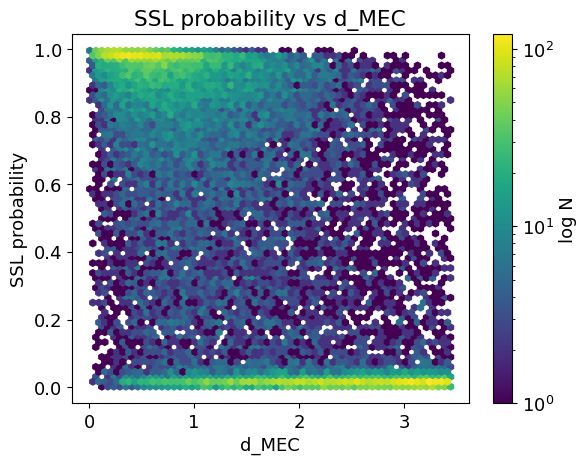

In [67]:
plt.hexbin(
    compare["d_mec"],
    compare["prob_ssl"],
    gridsize=60,
    bins="log",
    mincnt=1
)

plt.xlabel("d_MEC")
plt.ylabel("SSL probability")
plt.title("SSL probability vs d_MEC")
plt.colorbar(label="log N")
plt.show()

In [68]:
best_ssl = (
    pairs_A
    .sort_values("prob_ssl", ascending=False)
    .groupby("xmm_idx")
    .head(1)
)

best_ssl["d_mec"].describe()


count    35757.000000
mean         6.856518
std          6.844296
min          0.007624
25%          1.024607
50%          3.502895
75%         11.996676
max         24.039125
Name: d_mec, dtype: float64

In [69]:
pairs_A["d_mec"].describe()

count    190451.000000
mean         11.091188
std           6.207344
min           0.007624
25%           6.506438
50%          10.885321
75%          15.528135
max          24.041537
Name: d_mec, dtype: float64

In [70]:
from scipy.stats import spearmanr

rho, p = spearmanr(
    pairs_A["d_mec"],
    pairs_A["prob_ssl"]
)

print(f'rho: {rho:.4f}, p: {p}')

rho: -0.4679, p: 0.0


In [71]:
top_ssl = pairs_A.nlargest(5000, "prob_ssl")

print(top_ssl["d_mec"].describe())

count    5000.000000
mean        1.038795
std         1.905335
min         0.007624
25%         0.392466
50%         0.682408
75%         1.133052
max        23.987212
Name: d_mec, dtype: float64


In [72]:
bottom_ssl = pairs_A.nsmallest(5000, "prob_ssl")

print(bottom_ssl["d_mec"].describe())

count    5000.000000
mean       16.415747
std         5.140363
min         0.583505
25%        12.678820
50%        17.112646
75%        20.789674
max        24.034320
Name: d_mec, dtype: float64


In [73]:
new_ssl = pairs_A[
    (pairs_A["proba_xg"].isna())
    &
    (pairs_A["prob_ssl"] > 0.95)
]

In [74]:
len(new_ssl)

420

In [75]:
new_ssl["d_mec"].describe()

count    420.000000
mean       3.661524
std        5.115785
min        0.282047
25%        1.197176
50%        1.785272
75%        2.851407
max       23.987212
Name: d_mec, dtype: float64

In [76]:
pairs_A["prob_bin"] = pd.qcut(
    pairs_A["prob_ssl"],
    10,
    duplicates="drop"
)

pairs_A.groupby("prob_bin")["d_mec"].median()

prob_bin
(-0.00034, 0.00278]    15.905621
(0.00278, 0.00455]     13.651112
(0.00455, 0.00634]     12.840312
(0.00634, 0.00839]     12.351142
(0.00839, 0.0108]      11.669999
(0.0108, 0.014]        11.033378
(0.014, 0.019]         10.281934
(0.019, 0.0316]         9.456881
(0.0316, 0.322]         8.485781
(0.322, 0.996]          1.185972
Name: d_mec, dtype: float64

In [77]:
arches_pos = pairs_A[
    pairs_A["proba_xg"] > 0.9
].copy()

features = [
    "gaia_BP_RP",
    "gaia_Plx",
    "gaia_pmRA",
    "gaia_pmDE",
    "xmm_SC_HR2",
    "xmm_SC_EP_8_FLUX"
]

for col in features:

    a = pd.to_numeric(
        arches_pos[col],
        errors="coerce"
    ).dropna()

    b = pd.to_numeric(
        new_ssl[col],
        errors="coerce"
    ).dropna()

    print()
    print(col)

    print("ARCHES median:", np.median(a))
    print("SSL-only median:", np.median(b))


gaia_BP_RP
ARCHES median: 0.893224
SSL-only median: 0.6578485000000001

gaia_Plx
ARCHES median: 0.4011
SSL-only median: 0.04165

gaia_pmRA
ARCHES median: 0.064
SSL-only median: -0.035500000000000004

gaia_pmDE
ARCHES median: -0.07
SSL-only median: -0.006

xmm_SC_HR2
ARCHES median: -0.035430923
SSL-only median: -0.024937894

xmm_SC_EP_8_FLUX
ARCHES median: 2.4699391e-14
SSL-only median: 8.034722e-14


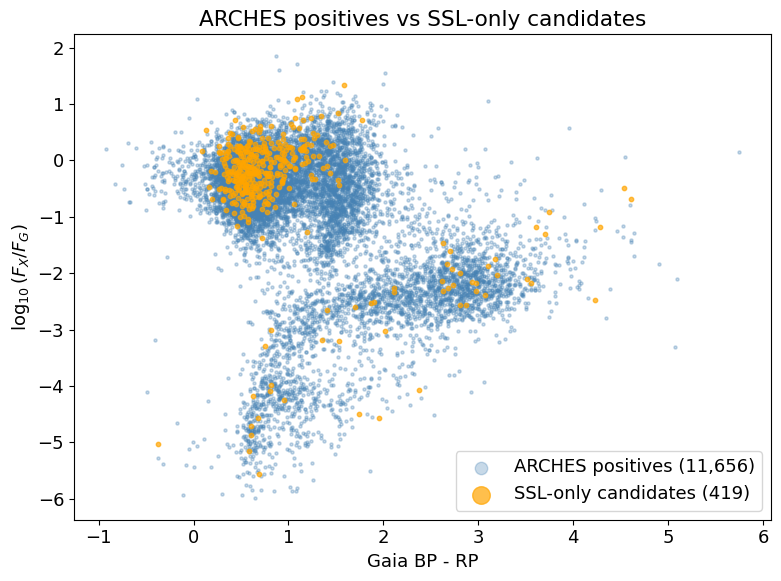

In [78]:
# ================================================================
# Fx/Fg vs BP-RP: ARCHES positives vs SSL-only candidates
# ================================================================

arches_pos = add_fx_fg_columns(arches_pos)
new_ssl = add_fx_fg_columns(new_ssl)

arches_plot = arches_pos[make_plot_mask(arches_pos)].copy()
ssl_plot = new_ssl[make_plot_mask(new_ssl)].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    arches_plot["BP_RP"],
    arches_plot["log_Fx_FG"],
    s=5,
    alpha=0.30,
    color="steelblue",
    label=f"ARCHES positives ({len(arches_plot):,})"
)

plt.scatter(
    ssl_plot["BP_RP"],
    ssl_plot["log_Fx_FG"],
    s=10,
    alpha=0.70,
    color="orange",
    label=f"SSL-only candidates ({len(ssl_plot):,})"
)

plt.xlabel("Gaia BP - RP")
plt.ylabel(r"$\log_{10}(F_X/F_G)$")
plt.title("ARCHES positives vs SSL-only candidates")
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

### Your medians suggest the SSL-only candidates are more AGN-like/extragalactic:

parallax ~ 0
proper motion ~ 0
higher X-ray flux
bluer BP-RP

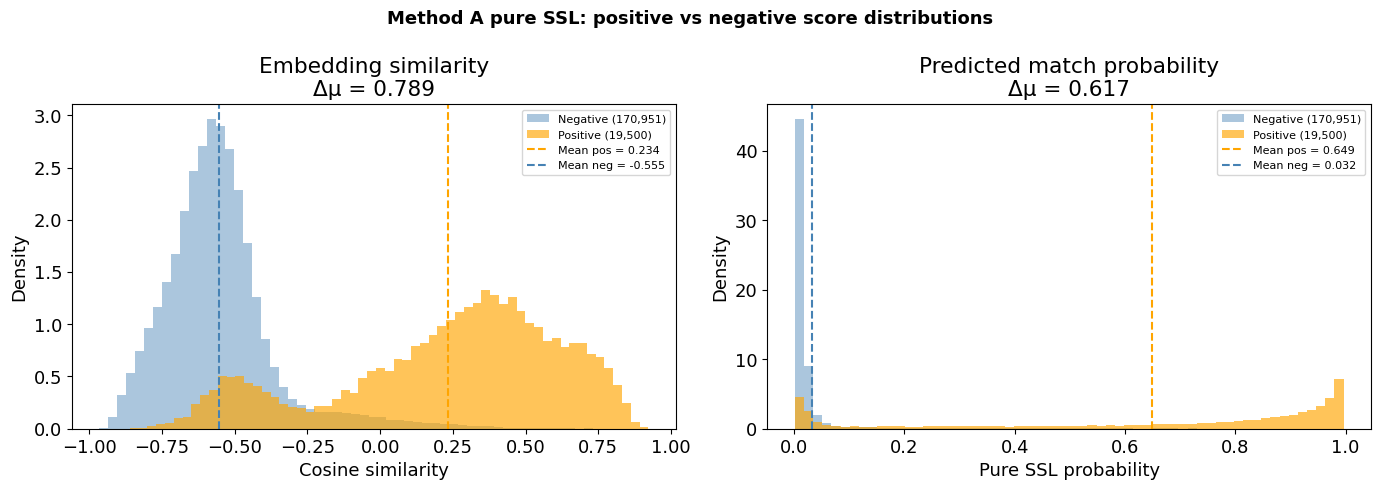


Method A pure SSL score separation
--------------------------------------------------------------------------------
Score                  mu_pos  sig_pos   mu_neg  sig_neg   Delta_mu       KS      p-value
--------------------------------------------------------------------------------
cosine similarity       0.234    0.387   -0.555    0.192      0.789    0.790     0.00e+00
SSL probability         0.649    0.350    0.032    0.099      0.617    0.790     0.00e+00


In [79]:
# ================================================================
# Cosine-similarity distributions: Method A pure SSL
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Make sure these exist:
# pairs_A["sim_ssl"]
# pairs_A["prob_ssl"]
# pairs_A["label_A"]

plot_df = pairs_A.dropna(
    subset=["sim_ssl", "prob_ssl", "label_A", "d_mec"]
).copy()

y = plot_df["label_A"].astype(int).values
sim = plot_df["sim_ssl"].values
prob = plot_df["prob_ssl"].values

sim_pos = sim[y == 1]
sim_neg = sim[y == 0]

prob_pos = prob[y == 1]
prob_neg = prob[y == 0]

# ================================================================
# Plot 1: cosine similarity
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    sim_neg,
    bins=60,
    density=True,
    alpha=0.45,
    color="steelblue",
    label=f"Negative ({len(sim_neg):,})"
)

axes[0].hist(
    sim_pos,
    bins=60,
    density=True,
    alpha=0.65,
    color="orange",
    label=f"Positive ({len(sim_pos):,})"
)

mu_pos = sim_pos.mean()
mu_neg = sim_neg.mean()

axes[0].axvline(
    mu_pos,
    color="orange",
    ls="--",
    lw=1.5,
    label=f"Mean pos = {mu_pos:.3f}"
)

axes[0].axvline(
    mu_neg,
    color="steelblue",
    ls="--",
    lw=1.5,
    label=f"Mean neg = {mu_neg:.3f}"
)

axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Density")
axes[0].set_title(
    f"Embedding similarity\nΔμ = {mu_pos - mu_neg:.3f}"
)
axes[0].legend(fontsize=8)

# ================================================================
# Plot 2: SSL probability
# ================================================================

axes[1].hist(
    prob_neg,
    bins=60,
    density=True,
    alpha=0.45,
    color="steelblue",
    label=f"Negative ({len(prob_neg):,})"
)

axes[1].hist(
    prob_pos,
    bins=60,
    density=True,
    alpha=0.65,
    color="orange",
    label=f"Positive ({len(prob_pos):,})"
)

mu_prob_pos = prob_pos.mean()
mu_prob_neg = prob_neg.mean()

axes[1].axvline(
    mu_prob_pos,
    color="orange",
    ls="--",
    lw=1.5,
    label=f"Mean pos = {mu_prob_pos:.3f}"
)

axes[1].axvline(
    mu_prob_neg,
    color="steelblue",
    ls="--",
    lw=1.5,
    label=f"Mean neg = {mu_prob_neg:.3f}"
)

axes[1].set_xlabel("Pure SSL probability")
axes[1].set_ylabel("Density")
axes[1].set_title(
    f"Predicted match probability\nΔμ = {mu_prob_pos - mu_prob_neg:.3f}"
)
axes[1].legend(fontsize=8)

plt.suptitle(
    "Method A pure SSL: positive vs negative score distributions",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ================================================================
# Summary statistics
# ================================================================

ks_sim, p_sim = ks_2samp(sim_pos, sim_neg)
ks_prob, p_prob = ks_2samp(prob_pos, prob_neg)

print("\nMethod A pure SSL score separation")
print("-" * 80)

print(
    f"{'Score':<20} "
    f"{'mu_pos':>8} {'sig_pos':>8} "
    f"{'mu_neg':>8} {'sig_neg':>8} "
    f"{'Delta_mu':>10} {'KS':>8} {'p-value':>12}"
)

print("-" * 80)

print(
    f"{'cosine similarity':<20} "
    f"{sim_pos.mean():8.3f} {sim_pos.std():8.3f} "
    f"{sim_neg.mean():8.3f} {sim_neg.std():8.3f} "
    f"{sim_pos.mean() - sim_neg.mean():10.3f} "
    f"{ks_sim:8.3f} {p_sim:12.2e}"
)

print(
    f"{'SSL probability':<20} "
    f"{prob_pos.mean():8.3f} {prob_pos.std():8.3f} "
    f"{prob_neg.mean():8.3f} {prob_neg.std():8.3f} "
    f"{prob_pos.mean() - prob_neg.mean():10.3f} "
    f"{ks_prob:8.3f} {p_prob:12.2e}"
)

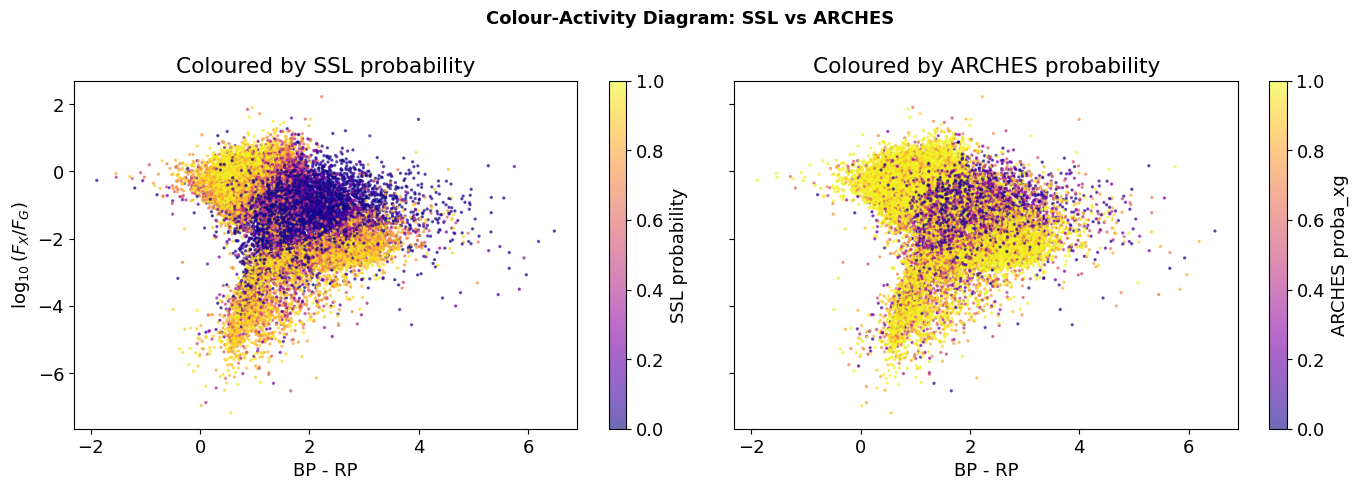

In [80]:
# ================================================================
# Colour-activity diagram
# SSL probability vs ARCHES probability
# ================================================================

Weff = 4052.97
ZP   = 2.5e-9

ps = compare.copy()

for col in [
    'gaia_Gmag',
    'gaia_BPmag',
    'gaia_RPmag',
    'xmm_SC_EP_8_FLUX'
]:
    ps[col] = pd.to_numeric(ps[col], errors='coerce')

ps['G_flux'] = (
    10**(-0.4 * ps['gaia_Gmag'])
    * Weff
    * ZP
)

ps['log_Fx_FG'] = np.log10(
    ps['xmm_SC_EP_8_FLUX']
    / ps['G_flux']
)

ps['BP_RP'] = (
    ps['gaia_BPmag']
    - ps['gaia_RPmag']
)

ps = (
    ps.replace([np.inf, -np.inf], np.nan)
      .dropna(
          subset=[
              'BP_RP',
              'log_Fx_FG',
              'prob_ssl',
              'proba_xg'
          ]
      )
)

if len(ps) > 30000:
    ps = ps.sample(30000, random_state=42)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharex=True,
    sharey=True
)

# =====================================================
# SSL probability
# =====================================================

sc1 = axes[0].scatter(
    ps['BP_RP'],
    ps['log_Fx_FG'],
    c=ps['prob_ssl'],
    s=2,
    alpha=0.6,
    cmap='plasma',
    vmin=0,
    vmax=1,
    rasterized=True
)

axes[0].set_xlabel('BP - RP')
axes[0].set_ylabel(r'$\log_{10}(F_X/F_G)$')
axes[0].set_title('Coloured by SSL probability')

plt.colorbar(
    sc1,
    ax=axes[0],
    label='SSL probability'
)

# =====================================================
# ARCHES probability
# =====================================================

sc2 = axes[1].scatter(
    ps['BP_RP'],
    ps['log_Fx_FG'],
    c=ps['proba_xg'],
    s=2,
    alpha=0.6,
    cmap='plasma',
    vmin=0,
    vmax=1,
    rasterized=True
)

axes[1].set_xlabel('BP - RP')
axes[1].set_title('Coloured by ARCHES probability')

plt.colorbar(
    sc2,
    ax=axes[1],
    label='ARCHES proba_xg'
)

plt.suptitle(
    'Colour-Activity Diagram: SSL vs ARCHES',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [81]:
# ================================================================
# Prepare SSL-only candidates
# ================================================================

ssl_only = new_ssl.copy()

for col in [
    'gaia_Gmag',
    'gaia_BPmag',
    'gaia_RPmag',
    'xmm_SC_EP_8_FLUX'
]:
    ssl_only[col] = pd.to_numeric(ssl_only[col], errors='coerce')

ssl_only['G_flux'] = (
    10**(-0.4 * ssl_only['gaia_Gmag'])
    * Weff
    * ZP
)

ssl_only['log_Fx_FG'] = np.log10(
    ssl_only['xmm_SC_EP_8_FLUX']
    / ssl_only['G_flux']
)

ssl_only['BP_RP'] = (
    ssl_only['gaia_BPmag']
    - ssl_only['gaia_RPmag']
)

ssl_only = (
    ssl_only
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['BP_RP', 'log_Fx_FG'])
)

print(f'SSL-only candidates plotted: {len(ssl_only):,}')

SSL-only candidates plotted: 420


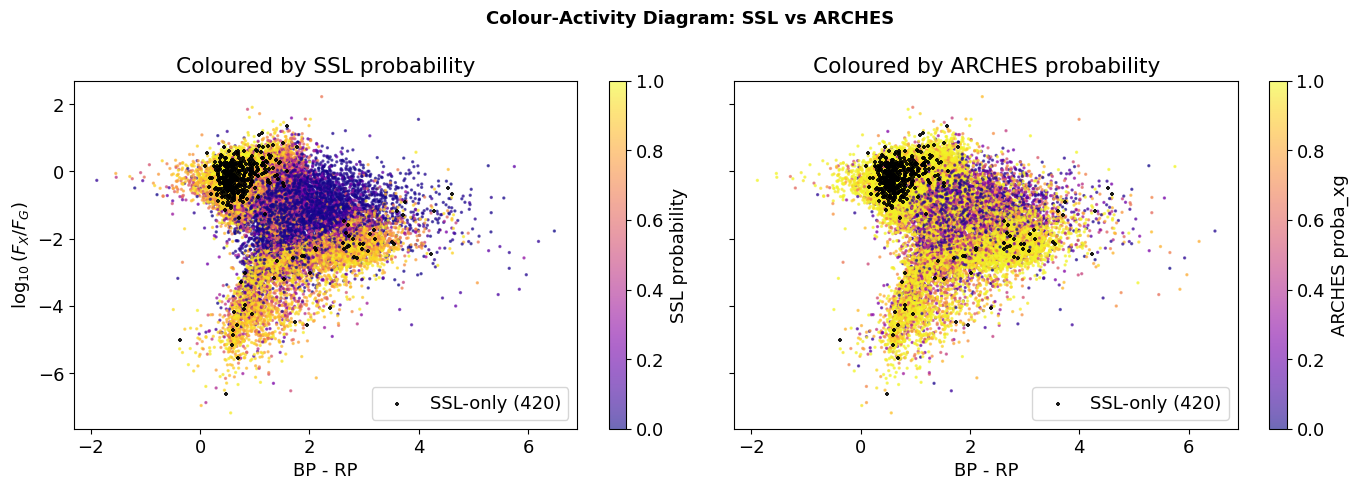

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# SSL probability
sc1 = axes[0].scatter(
    ps["BP_RP"], ps["log_Fx_FG"],
    c=ps["prob_ssl"],
    s=2, alpha=0.6,
    cmap="plasma", vmin=0, vmax=1,
    rasterized=True
)

axes[0].scatter(
    ssl_only["BP_RP"], ssl_only["log_Fx_FG"],
    marker="+", s=10,
    c="black",
    alpha=0.9,
    label=f"SSL-only ({len(ssl_only):,})"
)

axes[0].set_xlabel("BP - RP")
axes[0].set_ylabel(r"$\log_{10}(F_X/F_G)$")
axes[0].set_title("Coloured by SSL probability")
axes[0].legend()
plt.colorbar(sc1, ax=axes[0], label="SSL probability")


# ARCHES probability
sc2 = axes[1].scatter(
    ps["BP_RP"], ps["log_Fx_FG"],
    c=ps["proba_xg"],
    s=2, alpha=0.6,
    cmap="plasma", vmin=0, vmax=1,
    rasterized=True
)

axes[1].scatter(
    ssl_only["BP_RP"], ssl_only["log_Fx_FG"],
    marker="+", s=10,
    c="black",
    alpha=0.9,
    label=f"SSL-only ({len(ssl_only):,})"
)

axes[1].set_xlabel("BP - RP")
axes[1].set_title("Coloured by ARCHES probability")
axes[1].legend()
plt.colorbar(sc2, ax=axes[1], label="ARCHES proba_xg")

plt.suptitle("Colour-Activity Diagram: SSL vs ARCHES", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [83]:
import pandas as pd
import numpy as np

# ================================================================
# Top 20 SSL-only candidates
# ================================================================

top20 = (
    new_ssl
    .drop_duplicates(subset=["xmm_SRCID", "gaia_DR3Name"]) # Deduplicate first
    .sort_values("prob_ssl", ascending=False)
    .head(20)
    .copy()
)

top20["PM"] = np.sqrt(
    pd.to_numeric(top20["gaia_pmRA"], errors="coerce")**2 +
    pd.to_numeric(top20["gaia_pmDE"], errors="coerce")**2
)

cols = [
    "xmm_SRCID",
    "gaia_DR3Name",
    "prob_ssl",
    "d_mec",
    "proba_xg",
    "gaia_BP_RP",
    "gaia_Plx",
    "PM",
    "xmm_SC_HR2",
    "log_Fx_FG"
]

table = top20[cols].copy()

table.columns = [
    "xmm_SRCID",
    "gaia_DR3Name",
    "SSL_prob",
    "d_MEC",
    "ARCHES_prob",
    "BP-RP",
    "Parallax",
    "ProperMotion",
    "HR2",
    "log(Fx/Fg)"
]

table = table.round({
    "SSL_prob": 3,
    "d_MEC": 3,
    "ARCHES_prob": 3,
    "BP-RP": 3,
    "Parallax": 3,
    "ProperMotion": 3,
    "HR2": 3,
    "log(Fx/Fg)": 3
})

display(table)

,xmm_SRCID,gaia_DR3Name,SSL_prob,d_MEC,ARCHES_prob,BP-RP,Parallax,ProperMotion,HR2,log(Fx/Fg)
139036,206936628010003,Gaia DR3 2465470450931940608,0.996,1.233,NaN,1.134,-0.687,0.987,-0.114,0.387
132273,201123101010003,Gaia DR3 1535824676634548864,0.996,0.839,NaN,1.185,1.328,1.514,0.418,0.169
166046,201112906010002,Gaia DR3 1256404931968809088,0.995,8.633,NaN,0.979,-0.143,0.685,-0.046,-0.048
154254,200960201010004,Gaia DR3 4013388896477652864,0.995,1.016,NaN,0.642,0.050,0.066,0.054,-0.647
138738,201123703010002,Gaia DR3 2489688603282658688,0.995,1.041,NaN,0.450,-0.165,0.369,-0.119,-0.264
168396,201084602010006,Gaia DR3 2412417060681850112,0.995,0.875,NaN,0.959,-0.479,0.300,-0.036,-0.019
135427,201123701010005,Gaia DR3 2489663731127202048,0.994,0.809,NaN,0.584,-0.107,0.113,-0.079,-0.869
154269,200960201010011,Gaia DR3 4013443807634499712,0.994,8.379,NaN,0.742,2.128,1.192,0.150,0.315
151508,207439004010003,Gaia DR3 2635470410468237440,0.994,0.609,NaN,0.583,-0.322,1.031,-0.074,0.205
154280,200960201010010,Gaia DR3 4013491430231814144,0.994,1.185,NaN,0.322,0.219,0.560,0.021,-0.040


---
# SSL Cross-Matched Output Catalogue Generation

In [84]:
# from astropy.table import Table
# import numpy as np
# import pandas as pd

# # ================================================================
# # Helper: clean dataframe for FITS writing
# # ================================================================

# def clean_for_fits(df):
#     df = df.copy()

#     # Convert object columns to string so FITS handles them safely
#     for col in df.columns:
#         if df[col].dtype == "object":
#             df[col] = df[col].astype(str)

#     # Replace inf values
#     df = df.replace([np.inf, -np.inf], np.nan)

#     return df


# # ================================================================
# # 1. SSL-only newly found candidates
# # ================================================================

# # Deduplicate pairs right at the start
# ssl_new_fits = new_ssl.drop_duplicates(subset=["xmm_SRCID", "gaia_DR3Name"]).copy()

# # Add in_arches flag explicitly
# if "proba_xg" in ssl_new_fits.columns:
#     ssl_new_fits["in_arches"] = ssl_new_fits["proba_xg"].notna()
# else:
#     ssl_new_fits["in_arches"] = False

# # Add useful derived columns if missing
# if "PM" not in ssl_new_fits.columns:
#     ssl_new_fits["PM"] = np.sqrt(
#         pd.to_numeric(ssl_new_fits["gaia_pmRA"], errors="coerce")**2 +
#         pd.to_numeric(ssl_new_fits["gaia_pmDE"], errors="coerce")**2
#     )

# if "gaia_BP_RP" not in ssl_new_fits.columns:
#     ssl_new_fits["gaia_BP_RP"] = (
#         pd.to_numeric(ssl_new_fits["gaia_BPmag"], errors="coerce") -
#         pd.to_numeric(ssl_new_fits["gaia_RPmag"], errors="coerce")
#     )

# # Recommended compact columns
# ssl_new_cols = [
#     "xmm_SRCID",
#     "gaia_DR3Name",
#     "prob_ssl",
#     "sim_ssl",
#     "d_mec",
#     "proba_xg",
#     "in_arches",      
#     "gaia_BP_RP",
#     "gaia_Plx",
#     "gaia_pmRA",
#     "gaia_pmDE",
#     "PM",
#     "xmm_SC_HR2",
#     "xmm_SC_EP_8_FLUX",
#     "log_Fx_FG"
# ]

# ssl_new_cols = [c for c in ssl_new_cols if c in ssl_new_fits.columns]

# ssl_new_fits = ssl_new_fits[ssl_new_cols].copy()

# # --- SAFE MERGE: Deduplicate source catalogs to prevent row explosion ---
# xmm_dedup = xmm_df.drop_duplicates(subset=["xmm_SRCID"])
# gaia_dedup = gaia_df.drop_duplicates(subset=["gaia_DR3Name"])

# xmm_add_cols = [c for c in xmm_dedup.columns if c not in ssl_new_fits.columns or c == 'xmm_SRCID']
# gaia_add_cols = [c for c in gaia_dedup.columns if c not in ssl_new_fits.columns or c == 'gaia_DR3Name']

# # Merge original features using safe left join
# ssl_new_fits = pd.merge(ssl_new_fits, xmm_dedup[xmm_add_cols], on="xmm_SRCID", how="left")
# ssl_new_fits = pd.merge(ssl_new_fits, gaia_dedup[gaia_add_cols], on="gaia_DR3Name", how="left")
# # ------------------------------------------------------------------------

# ssl_new_fits = clean_for_fits(ssl_new_fits)

# Table.from_pandas(ssl_new_fits).write(
#     "ssl_only_new_candidates_fknni_longitudinal_split.fits",
#     overwrite=True
# )

# print(f"Wrote ssl_only_new_candidates_fknni_longitudinal_split.fits with {len(ssl_new_fits):,} rows")


# # ================================================================
# # 2. Full pairs table with SSL and ARCHES probabilities
# # ================================================================

# # Deduplicate pairs right at the start
# all_pairs_fits = pairs_A.drop_duplicates(subset=["xmm_SRCID", "gaia_DR3Name"]).copy()

# # Add flag for ARCHES match
# all_pairs_fits["in_arches"] = all_pairs_fits["proba_xg"].notna()

# # Add flag for SSL-only high-probability candidates
# all_pairs_fits["ssl_only_candidate"] = (
#     all_pairs_fits["proba_xg"].isna()
#     &
#     (all_pairs_fits["prob_ssl"] > 0.95)
# )

# if "PM" not in all_pairs_fits.columns:
#     all_pairs_fits["PM"] = np.sqrt(
#         pd.to_numeric(all_pairs_fits["gaia_pmRA"], errors="coerce")**2 +
#         pd.to_numeric(all_pairs_fits["gaia_pmDE"], errors="coerce")**2
#     )

# if "gaia_BP_RP" not in all_pairs_fits.columns:
#     all_pairs_fits["gaia_BP_RP"] = (
#         pd.to_numeric(all_pairs_fits["gaia_BPmag"], errors="coerce") -
#         pd.to_numeric(all_pairs_fits["gaia_RPmag"], errors="coerce")
#     )

# # Save useful full comparison columns
# all_cols = [
#     "xmm_SRCID",
#     "gaia_DR3Name",
#     "xmm_idx",
#     "gaia_idx",
#     "label_A",
#     "prob_ssl",
#     "sim_ssl",
#     "d_mec",
#     "proba_xg",
#     "in_arches",
#     "ssl_only_candidate",
#     "gaia_BP_RP",
#     "gaia_Plx",
#     "gaia_pmRA",
#     "gaia_pmDE",
#     "PM",
#     "gaia_Gmag",
#     "gaia_BPmag",
#     "gaia_RPmag",
#     "xmm_SC_HR2",
#     "xmm_SC_HR3",
#     "xmm_SC_EP_8_FLUX",
#     "log_Fx_FG"
# ]

# all_cols = [c for c in all_cols if c in all_pairs_fits.columns]

# all_pairs_fits = all_pairs_fits[all_cols].copy()


# # --- SAFE MERGE: Use deduplicated catalogs to prevent row explosion ---
# xmm_add_cols2 = [c for c in xmm_dedup.columns if c not in all_pairs_fits.columns or c == 'xmm_SRCID']
# gaia_add_cols2 = [c for c in gaia_dedup.columns if c not in all_pairs_fits.columns or c == 'gaia_DR3Name']

# # Merge original features using safe left join
# all_pairs_fits = pd.merge(all_pairs_fits, xmm_dedup[xmm_add_cols2], on="xmm_SRCID", how="left")
# all_pairs_fits = pd.merge(all_pairs_fits, gaia_dedup[gaia_add_cols2], on="gaia_DR3Name", how="left")
# # ----------------------------------------------------------------------


# all_pairs_fits = clean_for_fits(all_pairs_fits)

# Table.from_pandas(all_pairs_fits).write(
#     "all_pairs_ssl_arches_probs_fknni_longitudinal_split.fits",
#     overwrite=True
# )

# print(f"Wrote all_pairs_ssl_arches_probs_fknni_longitudinal_split.fits with {len(all_pairs_fits):,} rows")